## 1. Dataset Loading and Preprocessing

In [1]:
import os
from torch.utils.data import DataLoader, Dataset
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: Tesla P100-PCIE-16GB


In [3]:
# Custom dataset to load fingerprint images from folders
class FingerprintDataset(Dataset):
    def __init__(self, partial_dir, original_dir, transform=None):
        self.partial_dir = partial_dir
        self.original_dir = original_dir
        self.transform = transform

        # List all image files in the partial and original directories
        self.partial_images = sorted(os.listdir(self.partial_dir))
        self.original_images = sorted(os.listdir(self.original_dir))

        assert len(self.partial_images) == len(self.original_images), "Partial and original folder must have the same number of images"

    def __len__(self):
        return len(self.partial_images)

    def __getitem__(self, idx):
        # Load partial and original images
        partial_img_path = os.path.join(self.partial_dir, self.partial_images[idx])
        original_img_path = os.path.join(self.original_dir, self.original_images[idx])

        partial_img = self.load_image(partial_img_path)
        original_img = self.load_image(original_img_path)

        if self.transform:
            partial_img = self.transform(partial_img)
            original_img = self.transform(original_img)

        return partial_img, original_img

    def load_image(self, image_path):
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (128, 128))
        img_normalized = img_resized.astype("float32") / 255.0
        img_tensor = torch.tensor(img_normalized).unsqueeze(0)  # Add channel dimension
        return img_tensor


In [4]:
# Set your dataset directories here

partial_dir = '/kaggle/input/finger-print-dataset/DataSet/partial_fingerprints'
original_dir = '/kaggle/input/finger-print-dataset/DataSet/original_fingerprints'

# Create the dataset and dataloader
dataset = FingerprintDataset(partial_dir, original_dir)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

## 2. Defining the GAN Model
Generator
The generator takes the partial fingerprint and tries to generate a full fingerprint.

In [5]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Downsampling
        self.downsample = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        # Residual blocks
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(256) for _ in range(9)]
        )

        # Upsampling
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.final = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=7, stride=1, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.initial(x)
        x = self.downsample(x)
        x = self.res_blocks(x)
        x = self.upsample(x)
        return self.final(x)


Discriminator:
The discriminator distinguishes between real full fingerprints and fake ones generated by the generator.

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(1024*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


## 3. Setting up the GAN and Optimizers

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Optimizers
lr = 0.0002
beta1 = 0.5
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Learning rate scheduler
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=30, gamma=0.9)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=30, gamma=0.9)

# Loss function (binary cross-entropy)
criterion = nn.BCELoss()

# Labels for real and fake data with smoothing
real_label = 0.9
fake_label = 0.1

# Function to add noise to images (optional)
def add_noise(tensor, noise_factor=0.1):
    return tensor + noise_factor * torch.randn_like(tensor)

## 4. Training the GAN

In [8]:
# Function to train the GAN
def train_gan(generator, discriminator, dataloader, epochs=150):
    for epoch in range(epochs):
        for i, (partial_fingerprint, real_fingerprint) in enumerate(dataloader):
            partial_fingerprint = partial_fingerprint.to(device)
            real_fingerprint = real_fingerprint.to(device)

            # Train the Discriminator
            optimizer_D.zero_grad()

            # Add noise to real and fake fingerprints
            real_fingerprint = add_noise(real_fingerprint)
            real_output = discriminator(real_fingerprint)
            real_loss = criterion(real_output, torch.full_like(real_output, real_label).to(device))

            fake_fingerprint = generator(partial_fingerprint)
            fake_output = discriminator(add_noise(fake_fingerprint.detach()))
            fake_loss = criterion(fake_output, torch.full_like(fake_output, fake_label).to(device))

            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()

            # Train the Generator
            optimizer_G.zero_grad()
            fake_output = discriminator(fake_fingerprint)
            g_loss = criterion(fake_output, torch.ones_like(fake_output).to(device))

            g_loss.backward()
            optimizer_G.step()

        # Step the learning rate schedulers
        scheduler_G.step()
        scheduler_D.step()

        # Print progress
        if epoch % 1 == 0:
            print(f"Epoch [{epoch}/{epochs}] D loss: {d_loss.item():.4f}, G loss: {g_loss.item():.4f}")

# Train the GAN
train_gan(generator, discriminator, dataloader)


Epoch [0/150] D loss: 1.0553, G loss: 3.4520
Epoch [1/150] D loss: 1.2007, G loss: 2.2257
Epoch [2/150] D loss: 1.3049, G loss: 2.0640
Epoch [3/150] D loss: 1.1825, G loss: 1.1305
Epoch [4/150] D loss: 1.1722, G loss: 0.4648
Epoch [5/150] D loss: 1.1677, G loss: 1.3506
Epoch [6/150] D loss: 0.8558, G loss: 1.5148
Epoch [7/150] D loss: 1.2690, G loss: 0.2355
Epoch [8/150] D loss: 1.0174, G loss: 1.1177
Epoch [9/150] D loss: 2.4282, G loss: 3.8449
Epoch [10/150] D loss: 1.2290, G loss: 2.5877
Epoch [11/150] D loss: 1.0350, G loss: 0.0458
Epoch [12/150] D loss: 1.8200, G loss: 1.4024
Epoch [13/150] D loss: 1.2541, G loss: 0.5191
Epoch [14/150] D loss: 0.9591, G loss: 0.1258
Epoch [15/150] D loss: 1.4212, G loss: 2.5770
Epoch [16/150] D loss: 1.0023, G loss: 0.0981
Epoch [17/150] D loss: 1.2407, G loss: 1.1680
Epoch [18/150] D loss: 1.1653, G loss: 0.9376
Epoch [19/150] D loss: 0.9812, G loss: 0.2122
Epoch [20/150] D loss: 0.8842, G loss: 0.0868
Epoch [21/150] D loss: 1.0096, G loss: 0.028

## 5. Generate Full Fingerprints from Partial Images

In [9]:
def generate_full_fingerprint(partial_fingerprint):
    with torch.no_grad():
        partial_fingerprint = partial_fingerprint.to(device)
        generated_fingerprint = generator(partial_fingerprint)
        return generated_fingerprint.cpu().numpy()

# Example usage
partial_fingerprint, _ = next(iter(dataloader))
full_fingerprint = generate_full_fingerprint(partial_fingerprint)

## Test Images after 150 Epochs

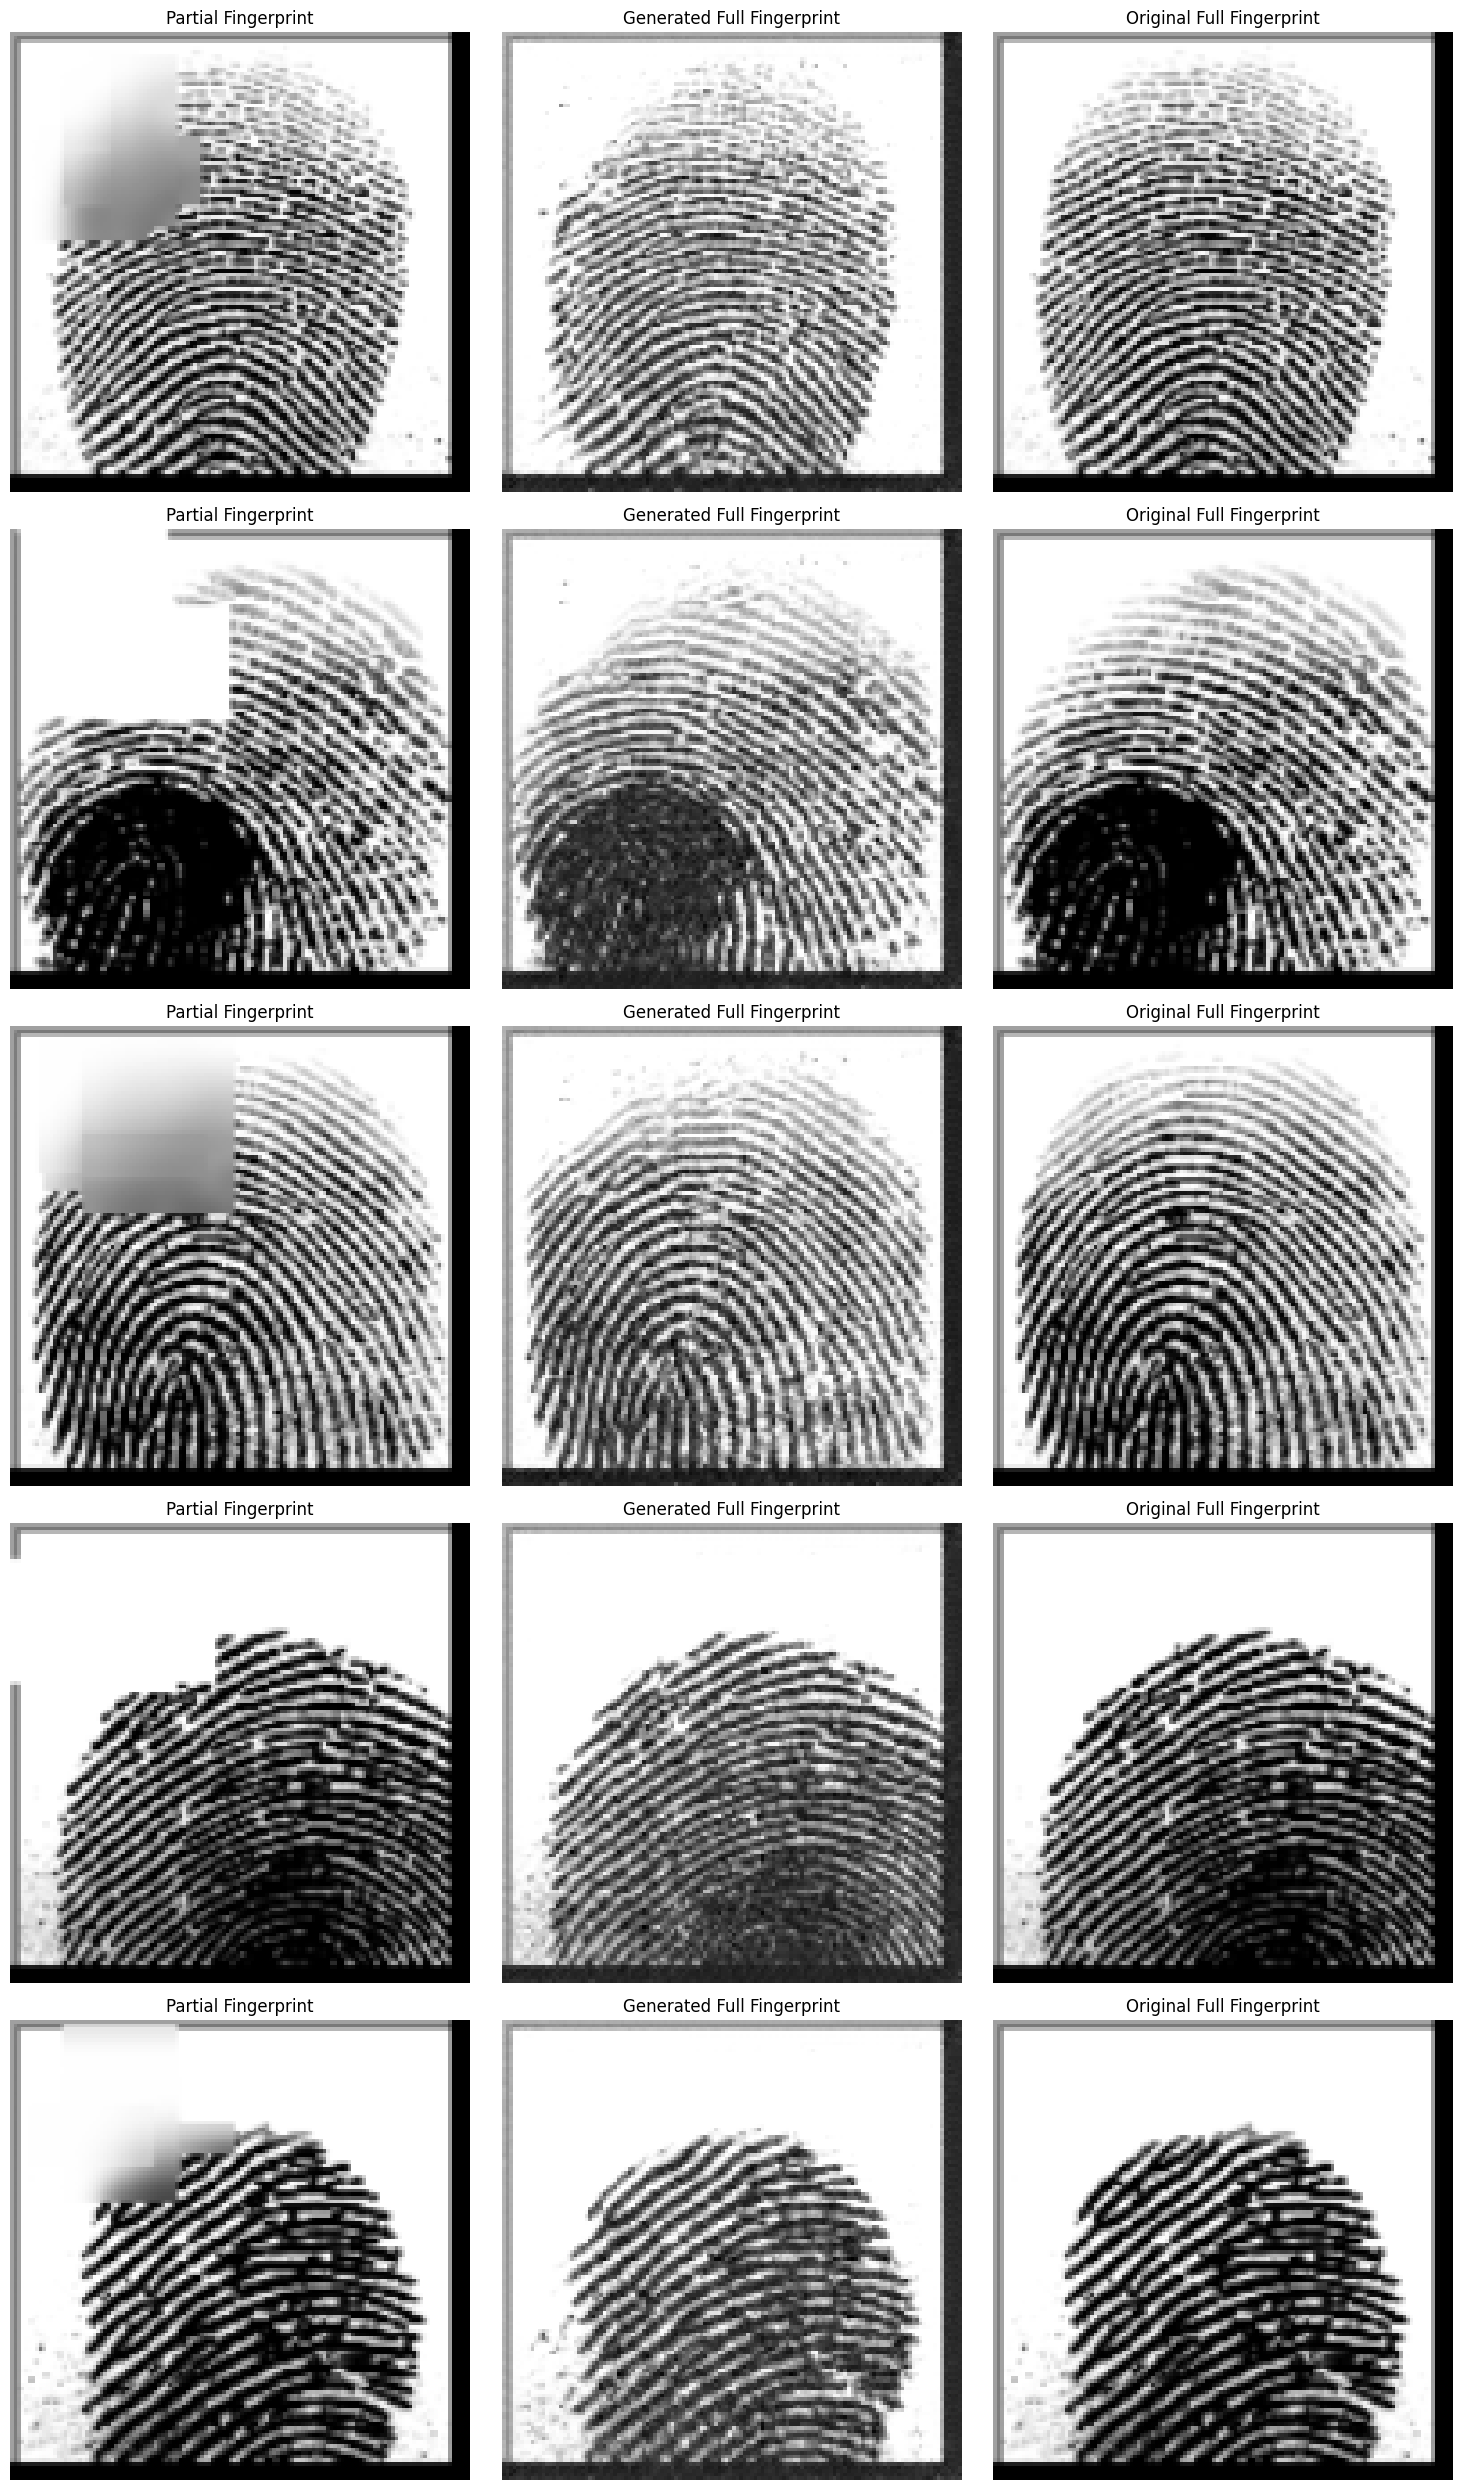

In [10]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


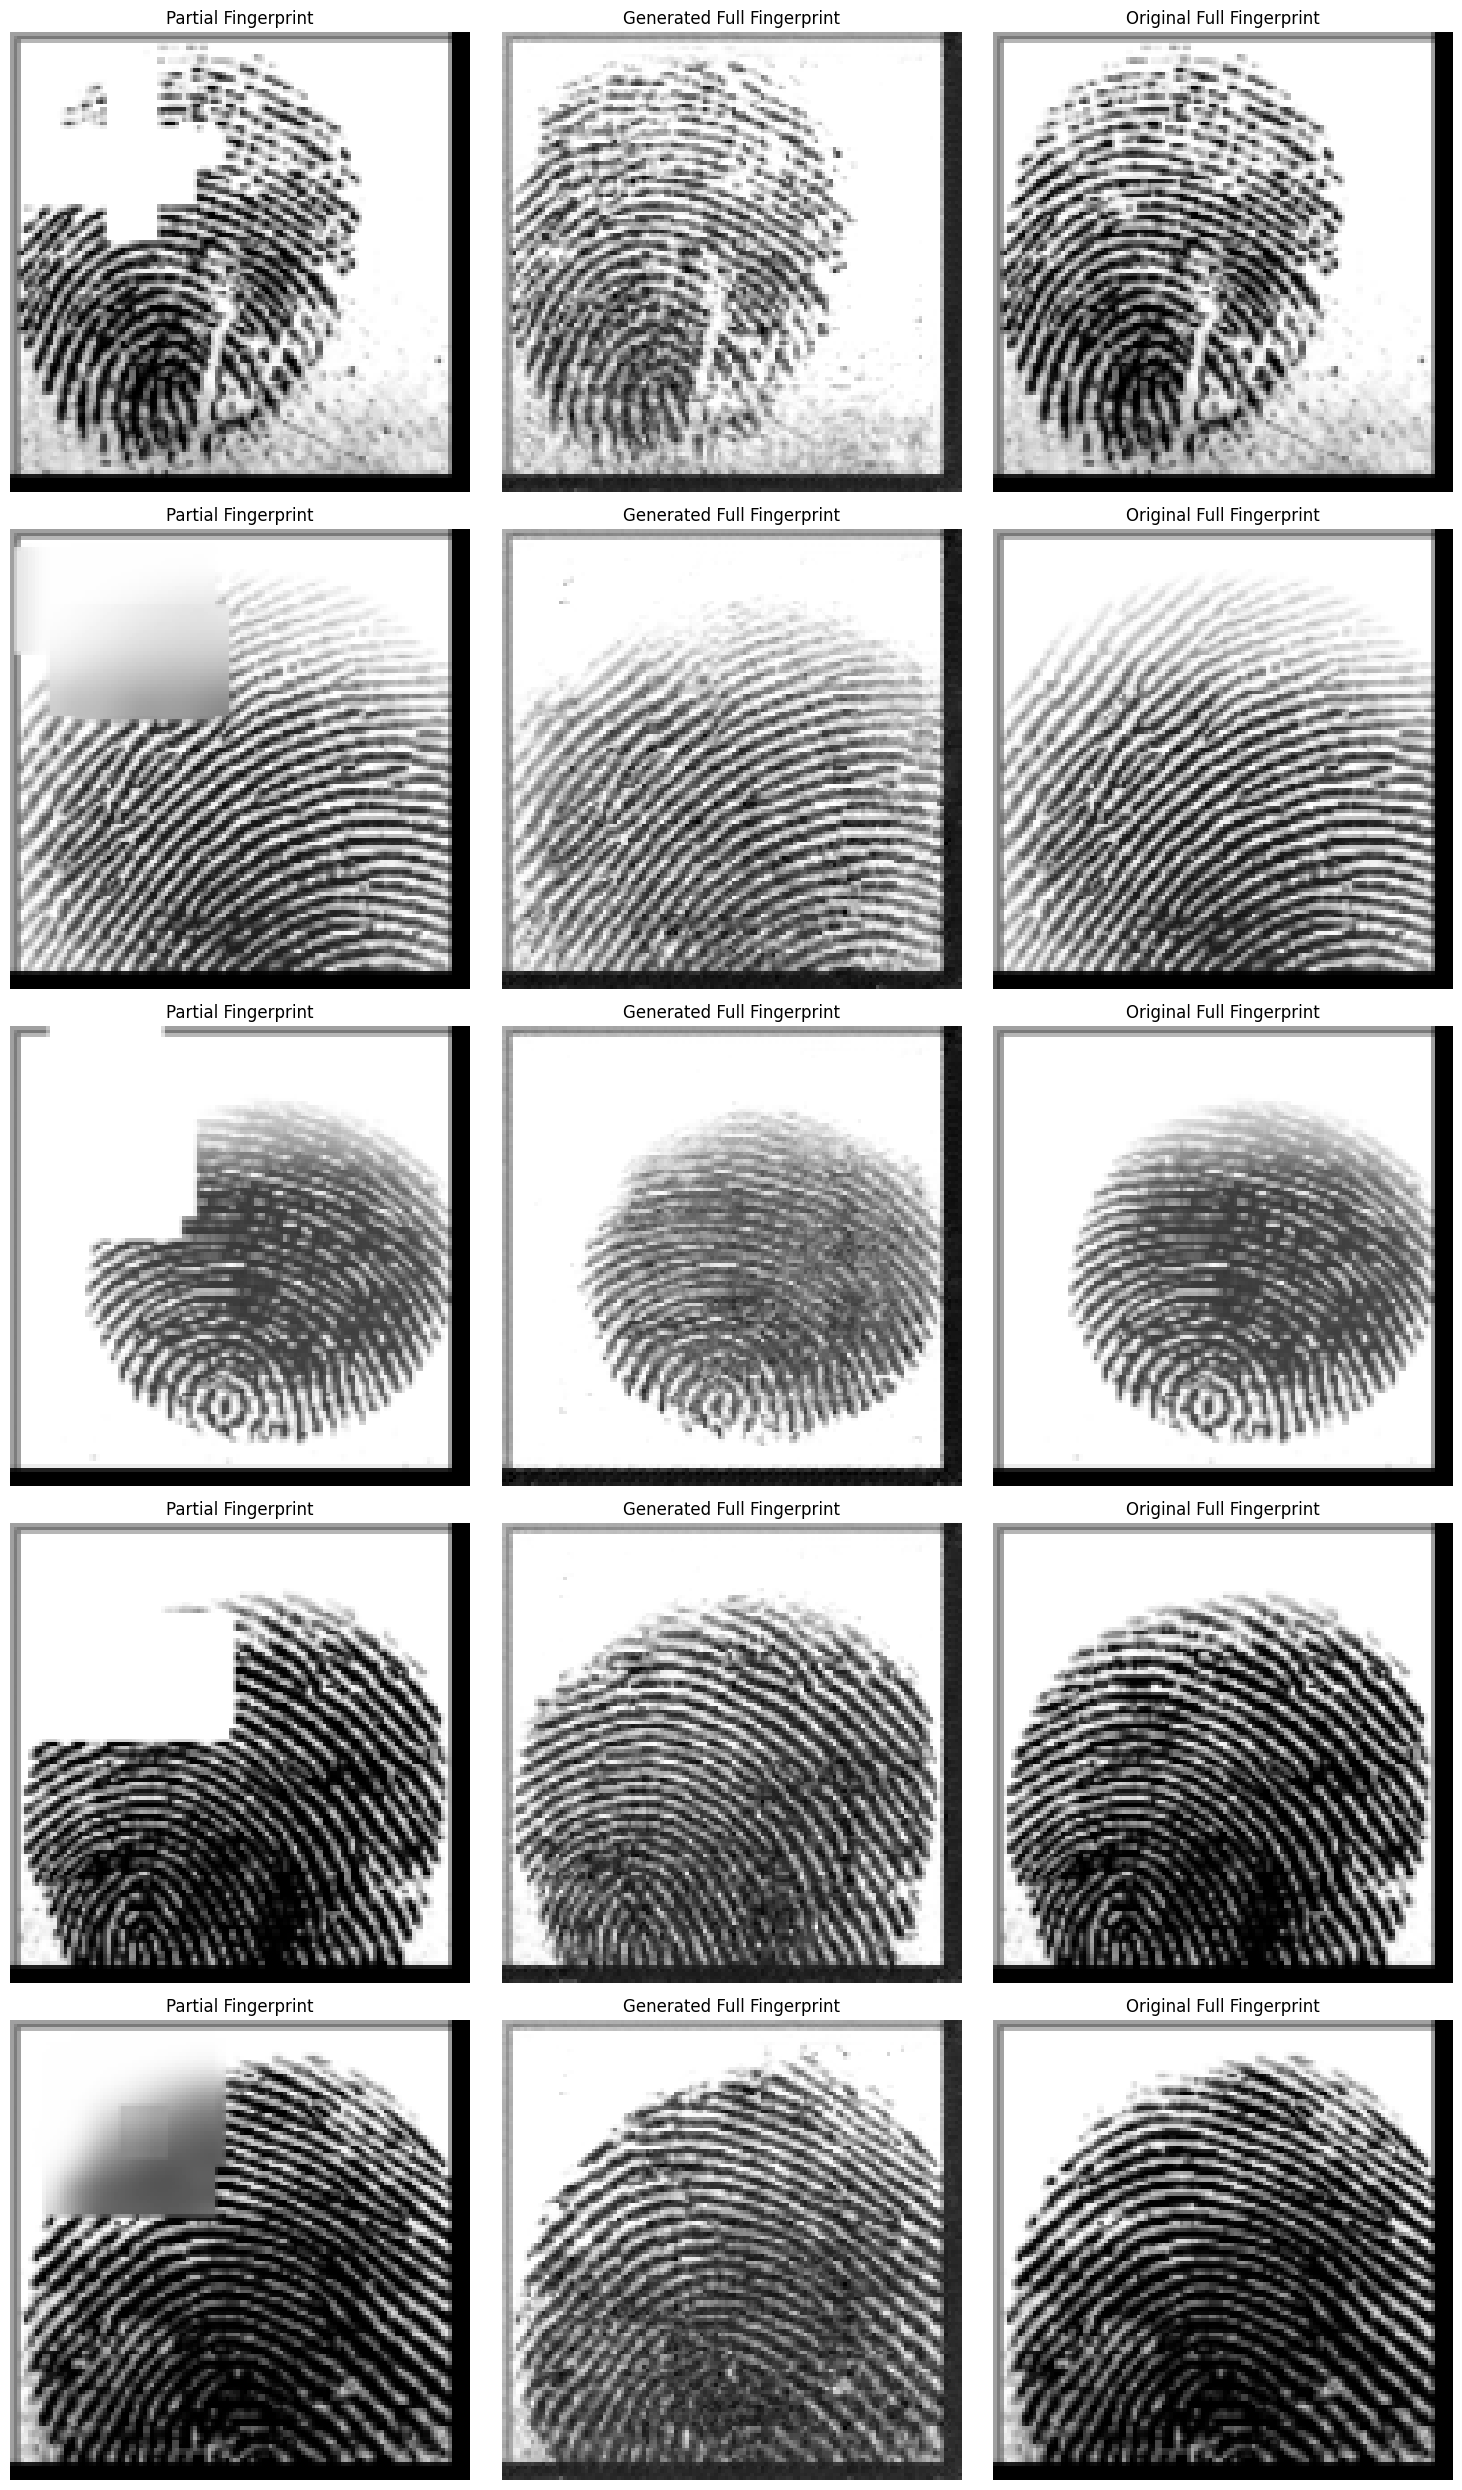

In [11]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


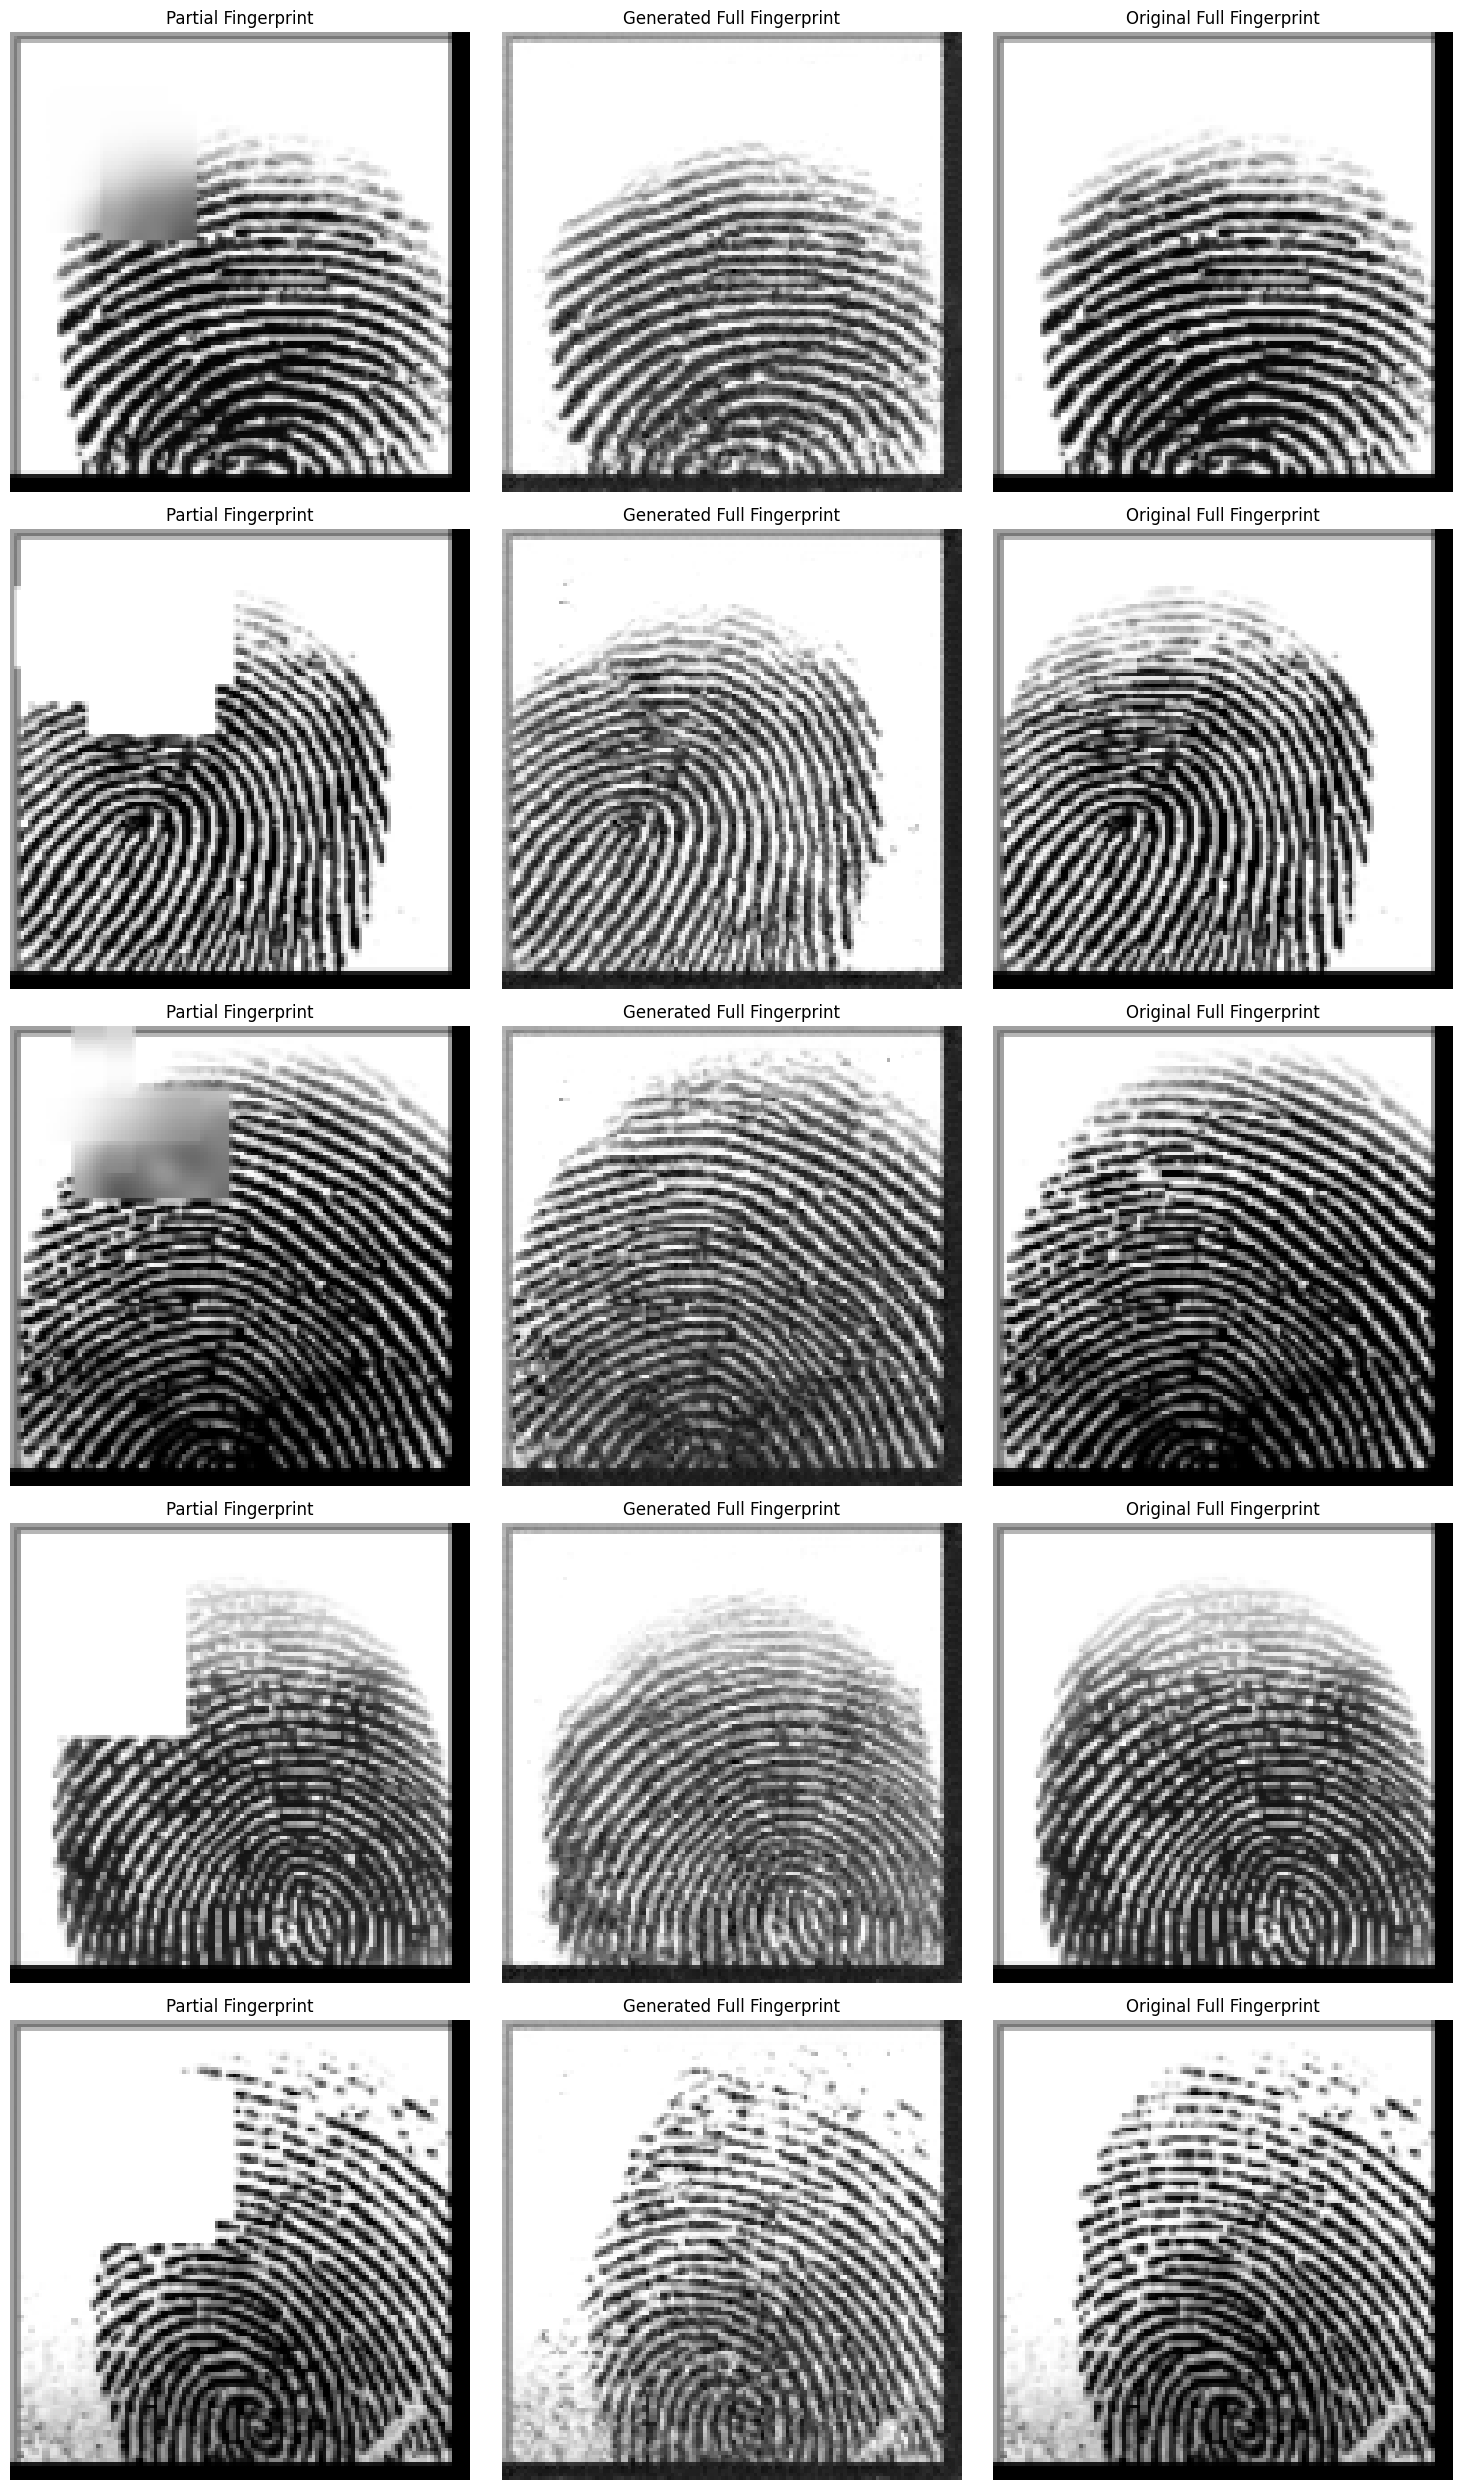

In [12]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


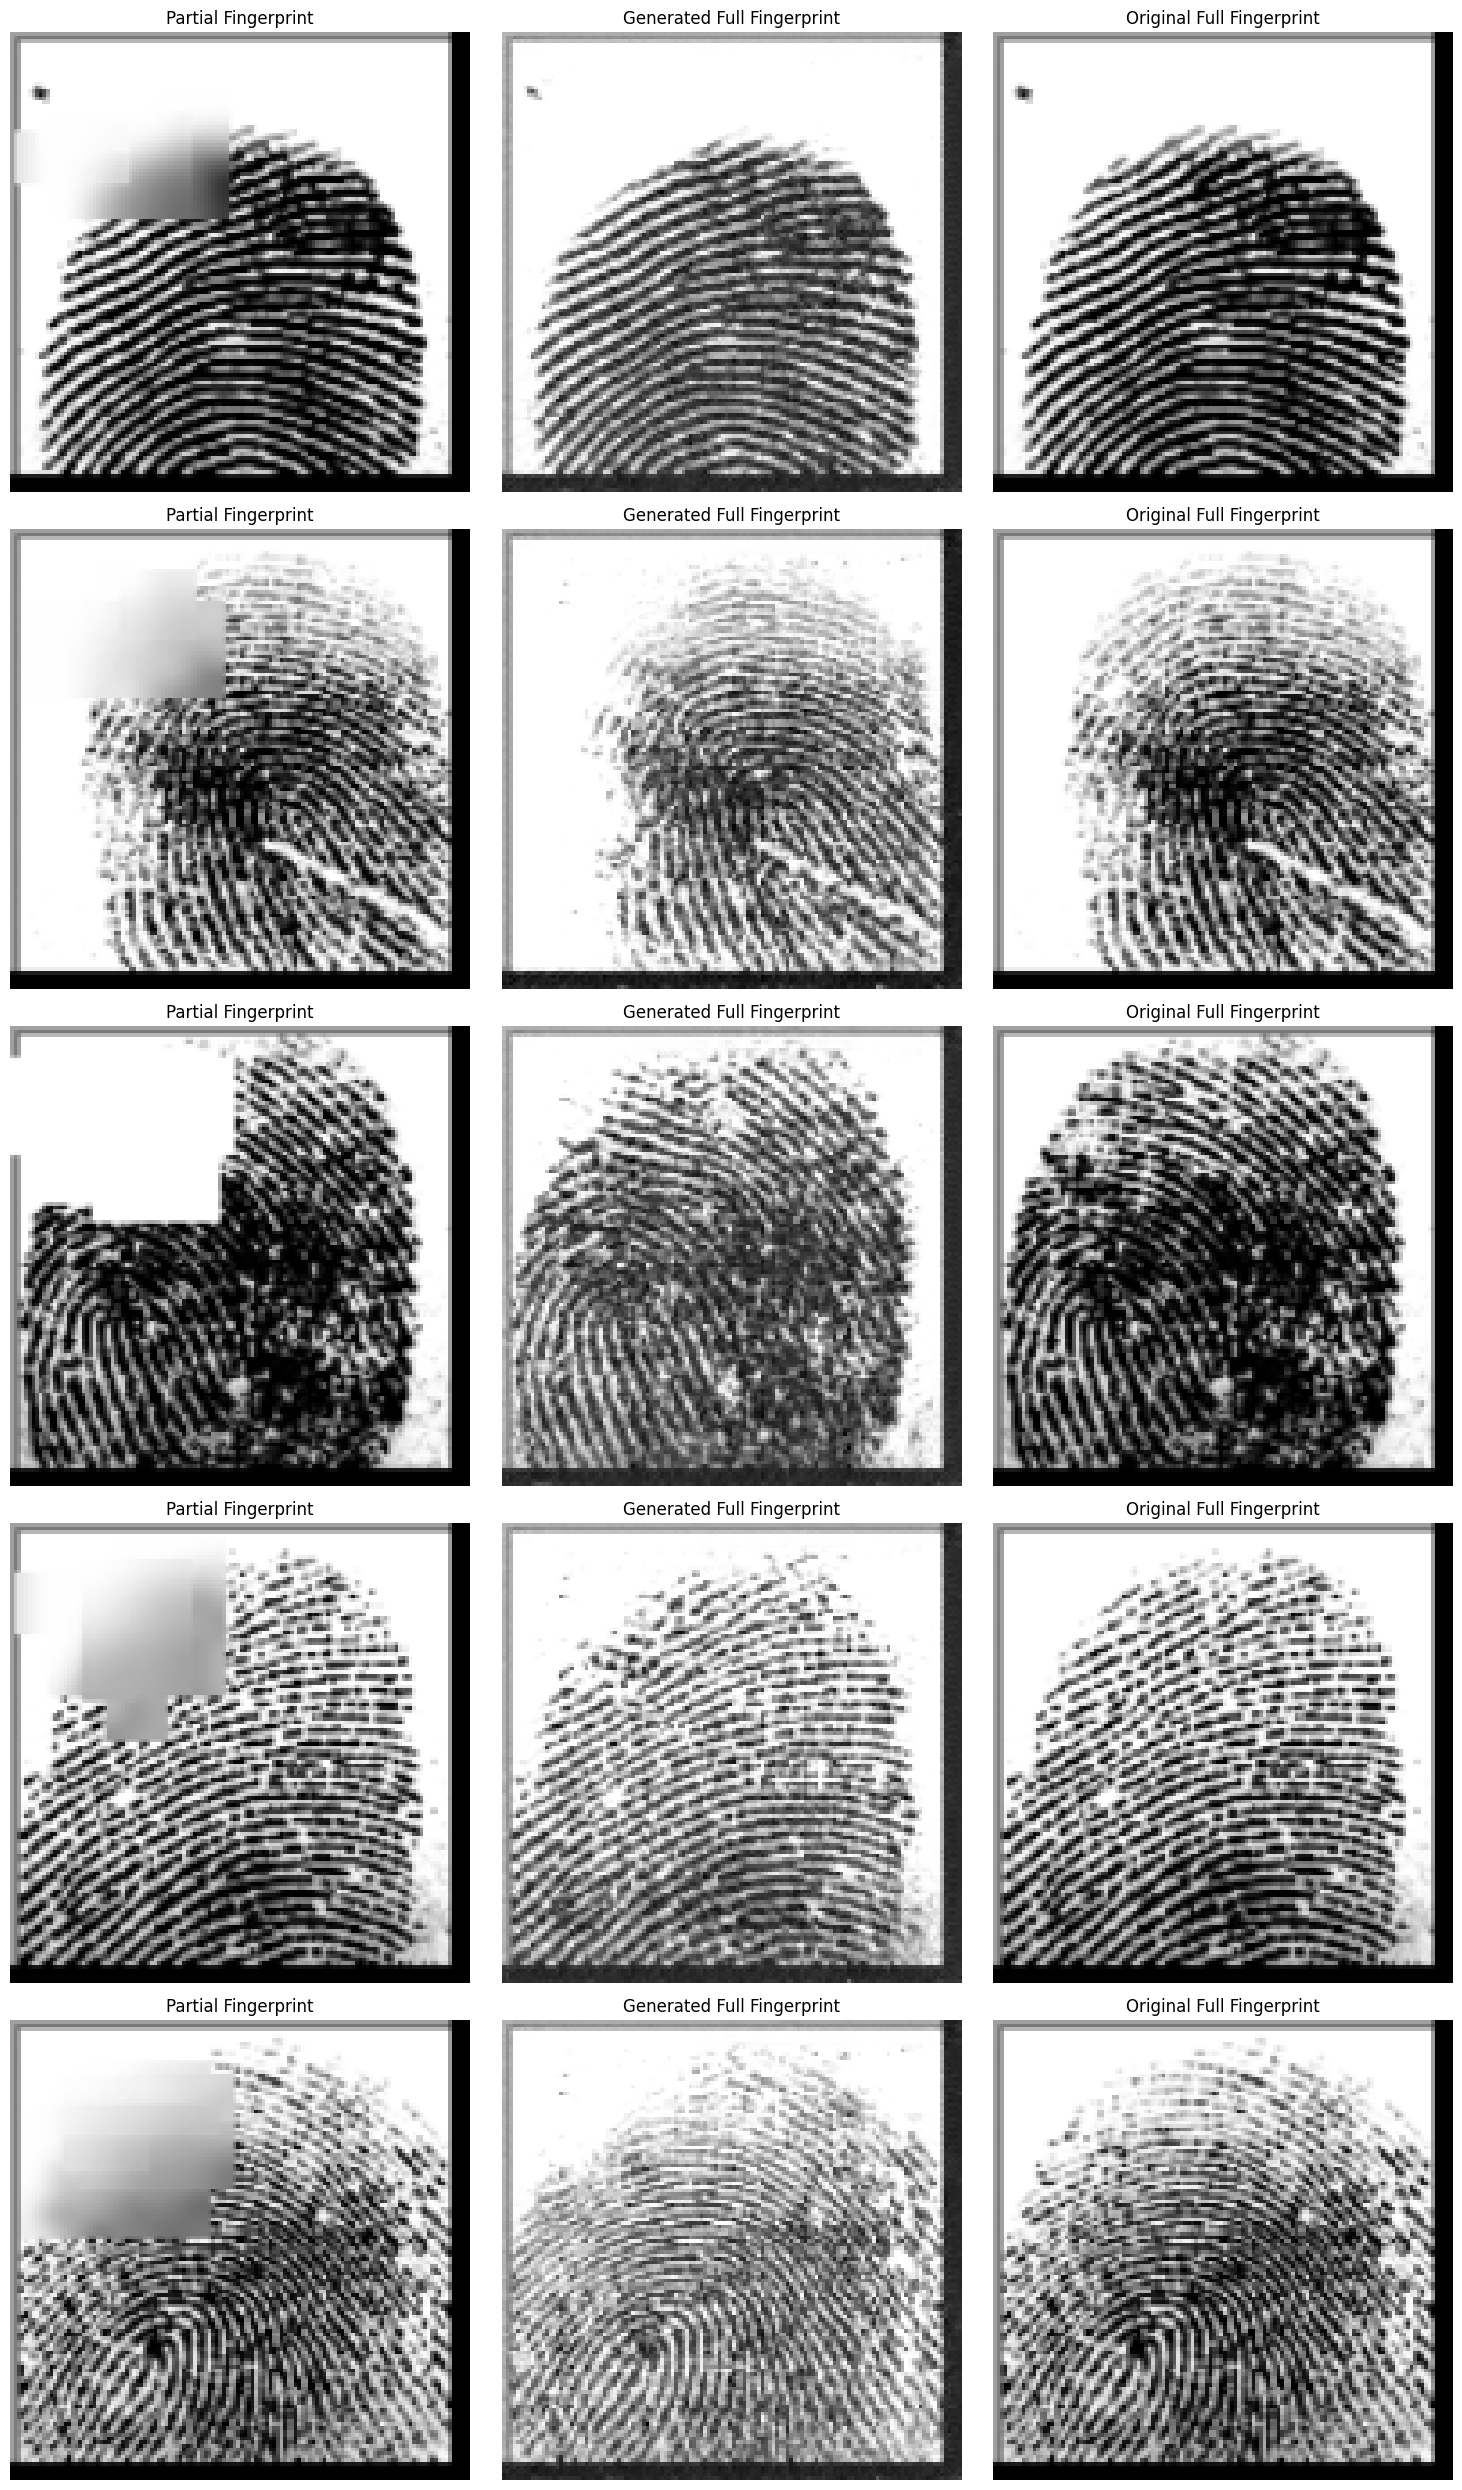

In [13]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


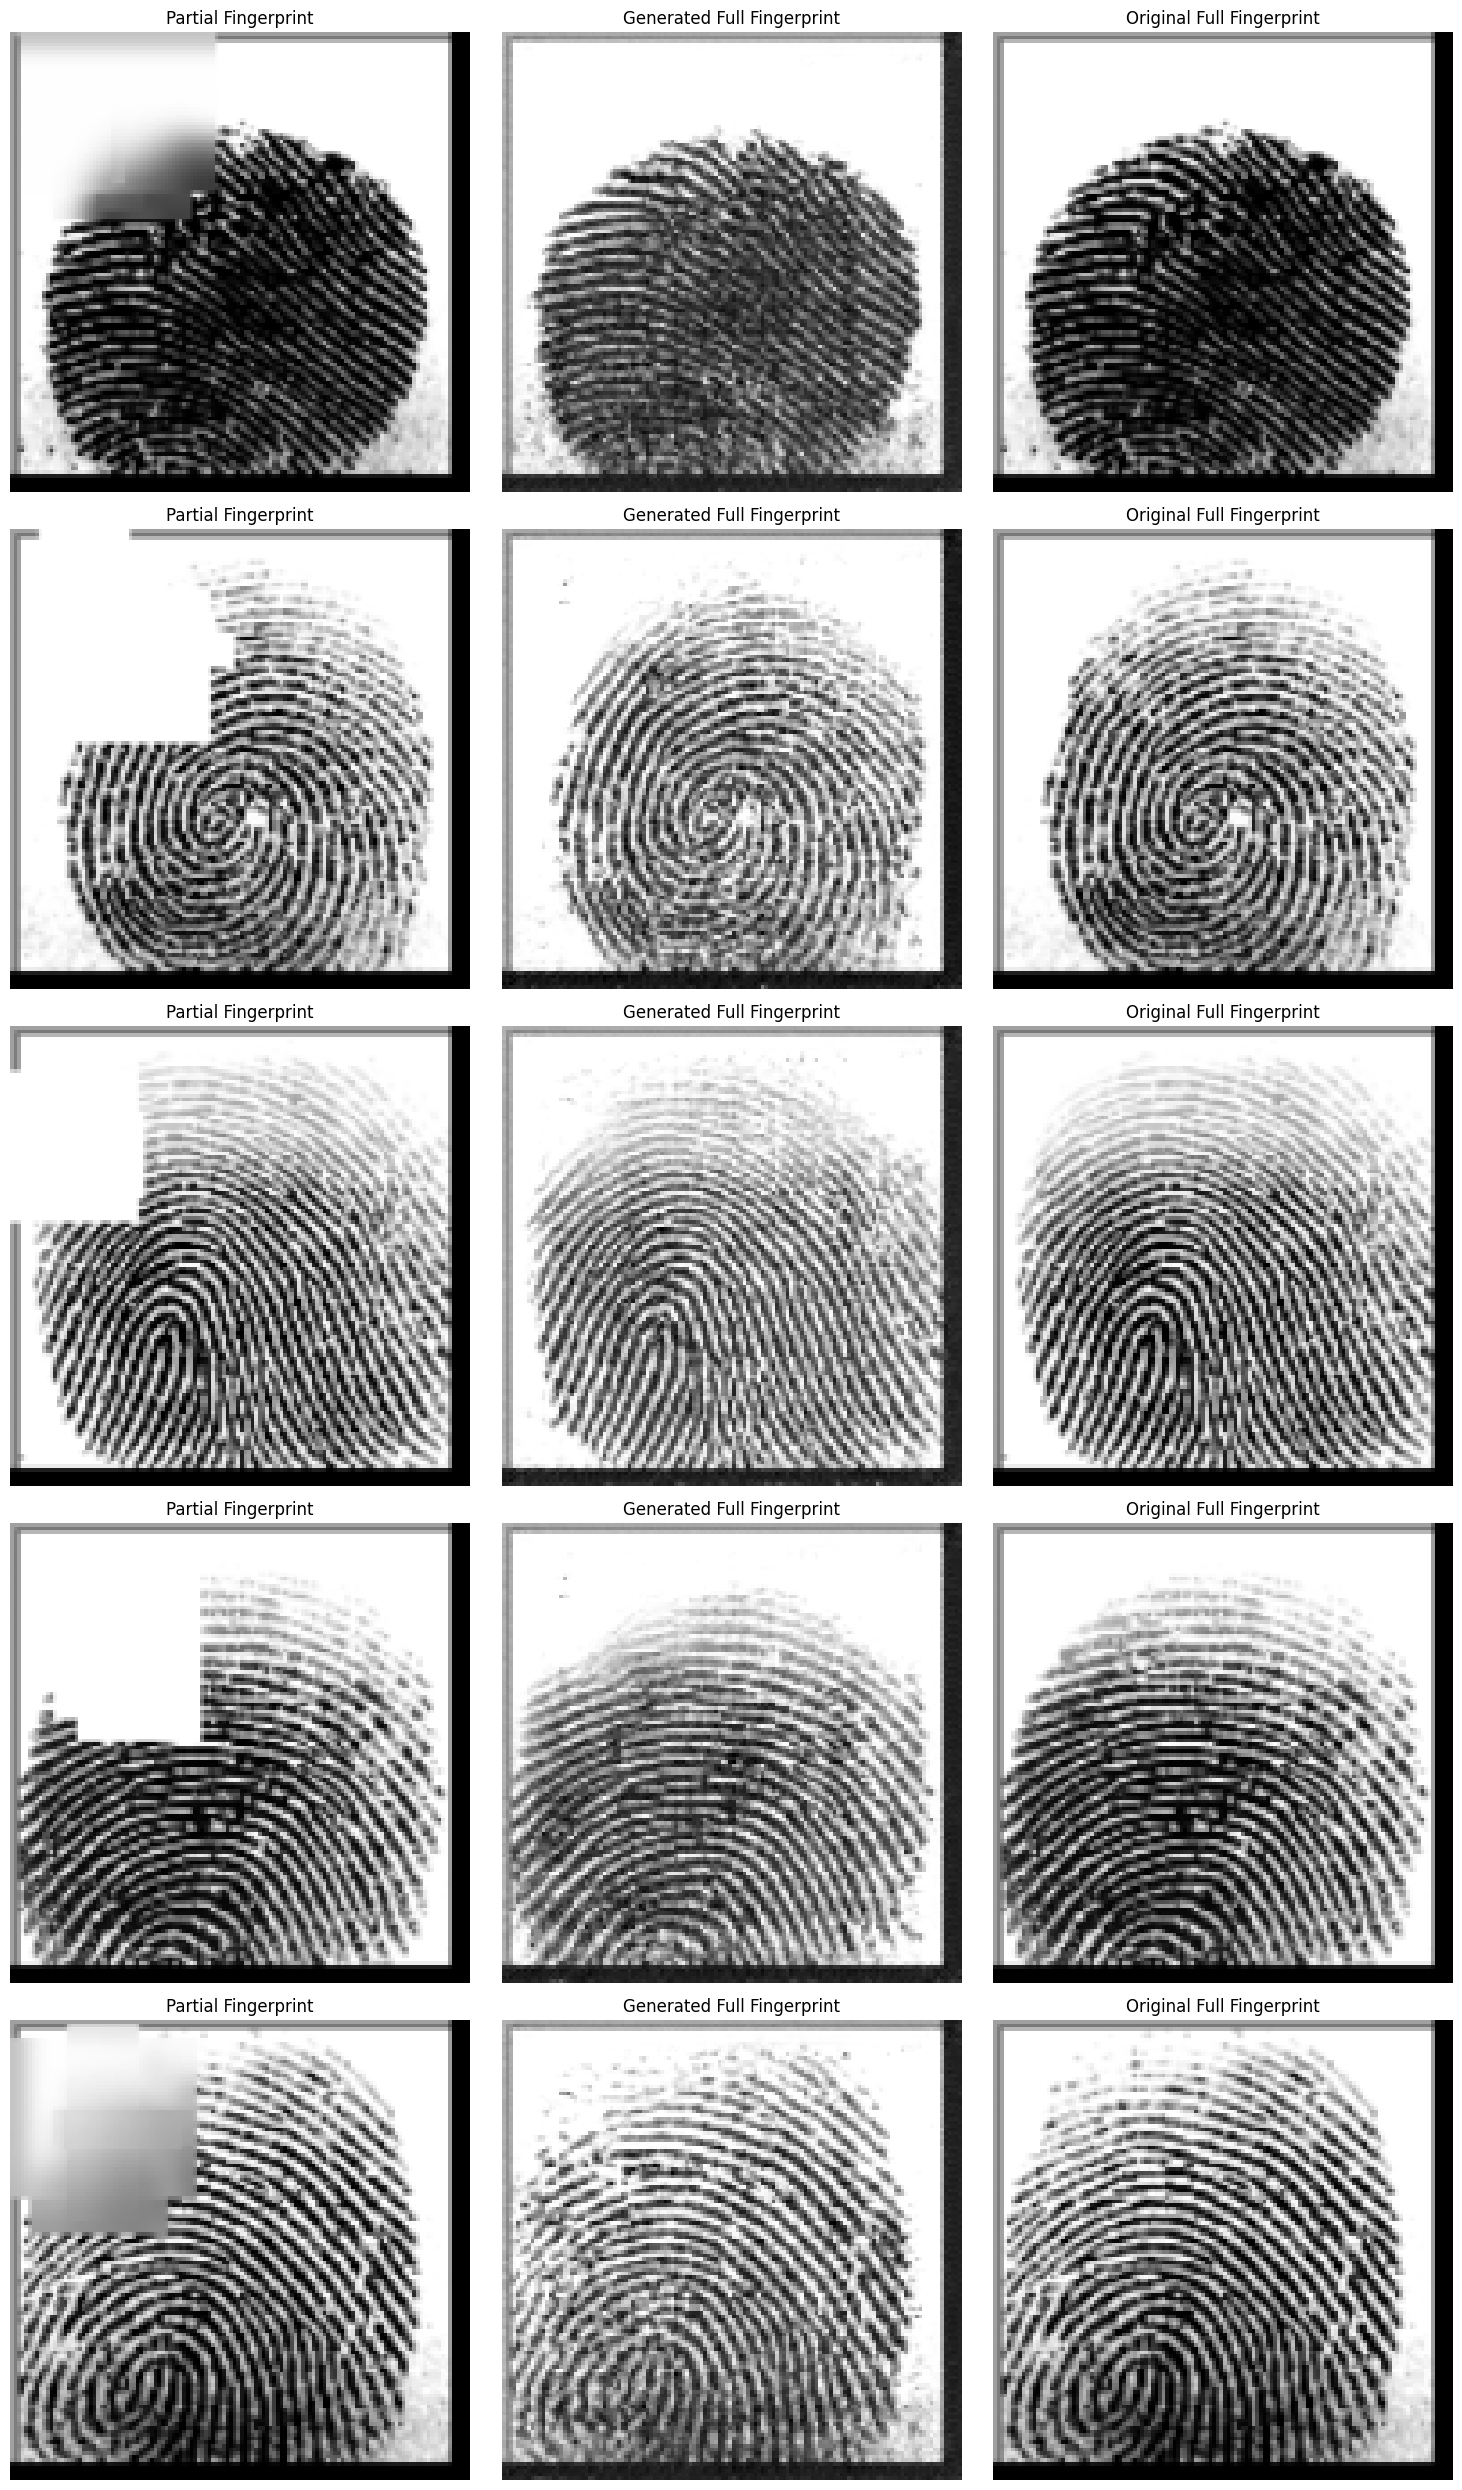

In [14]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


## Saving the 150 epochs model

In [15]:
import torch

# Function to save the GAN model
def save_gan_model(generator, discriminator, optimizer_G, optimizer_D, epoch, save_path="/kaggle/working/FingerPrint2_model.pth"):
    # Create a dictionary containing the models and optimizers' state dicts
    checkpoint = {
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'epoch': epoch
    }
    
    # Save the checkpoint to the given path
    torch.save(checkpoint, save_path)
    print(f"Model saved successfully at epoch {epoch} in {save_path}")

# Example of usage after training
save_gan_model(generator, discriminator, optimizer_G, optimizer_D, epoch=10, save_path="/kaggle/working/FingerPrint2_model.pth")


Model saved successfully at epoch 10 in /kaggle/working/FingerPrint2_model.pth


## Loading the 150 epochs model

In [16]:
import torch

# Function to load the GAN model
def load_gan_model(generator, discriminator, optimizer_G, optimizer_D, load_path="F_model.pth"):
    # Load the checkpoint from the file and map it to the appropriate device (CPU or GPU)
    checkpoint = torch.load(load_path)

    # Load the state dicts into the generator and discriminator
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

    # Load the state dicts into the optimizers
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])

    # Return the epoch to continue training from
    epoch = checkpoint['epoch']
    print(f"Model loaded successfully from {load_path}, resuming from epoch {epoch}")

    return epoch

# Example of usage when resuming from a checkpoint
start_epoch = load_gan_model(generator, discriminator, optimizer_G, optimizer_D, load_path = "/kaggle/working/FingerPrint2_model.pth")

/tmp/ipykernel_36/1332183909.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(load_path)


Model loaded successfully from /kaggle/working/FingerPrint2_model.pth, resuming from epoch 10


## Checking accuracy of 150 epochs models

In [17]:
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader

In [18]:
def evaluate_generator_ssim(generator, dataloader, device):
    generator.eval()  # Set generator to evaluation mode
    total_ssim = 0.0
    count = 0

    with torch.no_grad():
        for partial_images, original_images in dataloader:
            partial_images = partial_images.to(device)
            original_images = original_images.to(device)

            # Generate images
            generated_images = generator(partial_images)

            # Compute SSIM between generated and original images
            for i in range(generated_images.size(0)):
                gen_img = generated_images[i].cpu().numpy().squeeze()  # Convert to numpy array and remove channel dimension
                orig_img = original_images[i].cpu().numpy().squeeze()

                # SSIM expects images in the range [0, 255]
                gen_img = (gen_img * 255).astype("uint8")
                orig_img = (orig_img * 255).astype("uint8")

                score = ssim(gen_img, orig_img, data_range=gen_img.max() - gen_img.min())
                total_ssim += score
                count += 1

    avg_ssim = total_ssim / count
    print(f"Average SSIM for generated images: {avg_ssim:.4f}")
    return avg_ssim

In [20]:
def evaluate_discriminator_accuracy(generator, discriminator, dataloader, device):
    generator.eval()
    discriminator.eval()
    real_correct = 0
    fake_correct = 0
    total = 0

    with torch.no_grad():
        for partial_images, original_images in dataloader:
            partial_images = partial_images.to(device)
            original_images = original_images.to(device)

            # Generate fake images
            generated_images = generator(partial_images)

            # Discriminator output for real images
            real_labels = torch.full((original_images.size(0),), 1.0, dtype=torch.float, device=device)
            real_output = discriminator(original_images).view(-1)
            real_correct += ((real_output > 0.5) == real_labels).sum().item()

            # Discriminator output for fake images
            fake_labels = torch.full((generated_images.size(0),), 0.0, dtype=torch.float, device=device)
            fake_output = discriminator(generated_images.detach()).view(-1)
            fake_correct += ((fake_output < 0.5) == fake_labels).sum().item()

            total += original_images.size(0)

    real_acc = real_correct / total * 100
    fake_acc = fake_correct / total * 100

    print(f"Discriminator Accuracy on Real Images: {real_acc:.2f}%")
    print(f"Discriminator Accuracy on Fake Images: {fake_acc:.2f}%")
    return real_acc, fake_acc

In [21]:
evaluate_generator_ssim(generator, dataloader, device)
evaluate_discriminator_accuracy(generator, discriminator, dataloader, device)

Average SSIM for generated images: 0.6421
Discriminator Accuracy on Real Images: 99.28%
Discriminator Accuracy on Fake Images: 91.57%


(99.28333333333333, 91.56666666666666)

## Test Images after 100 epochs

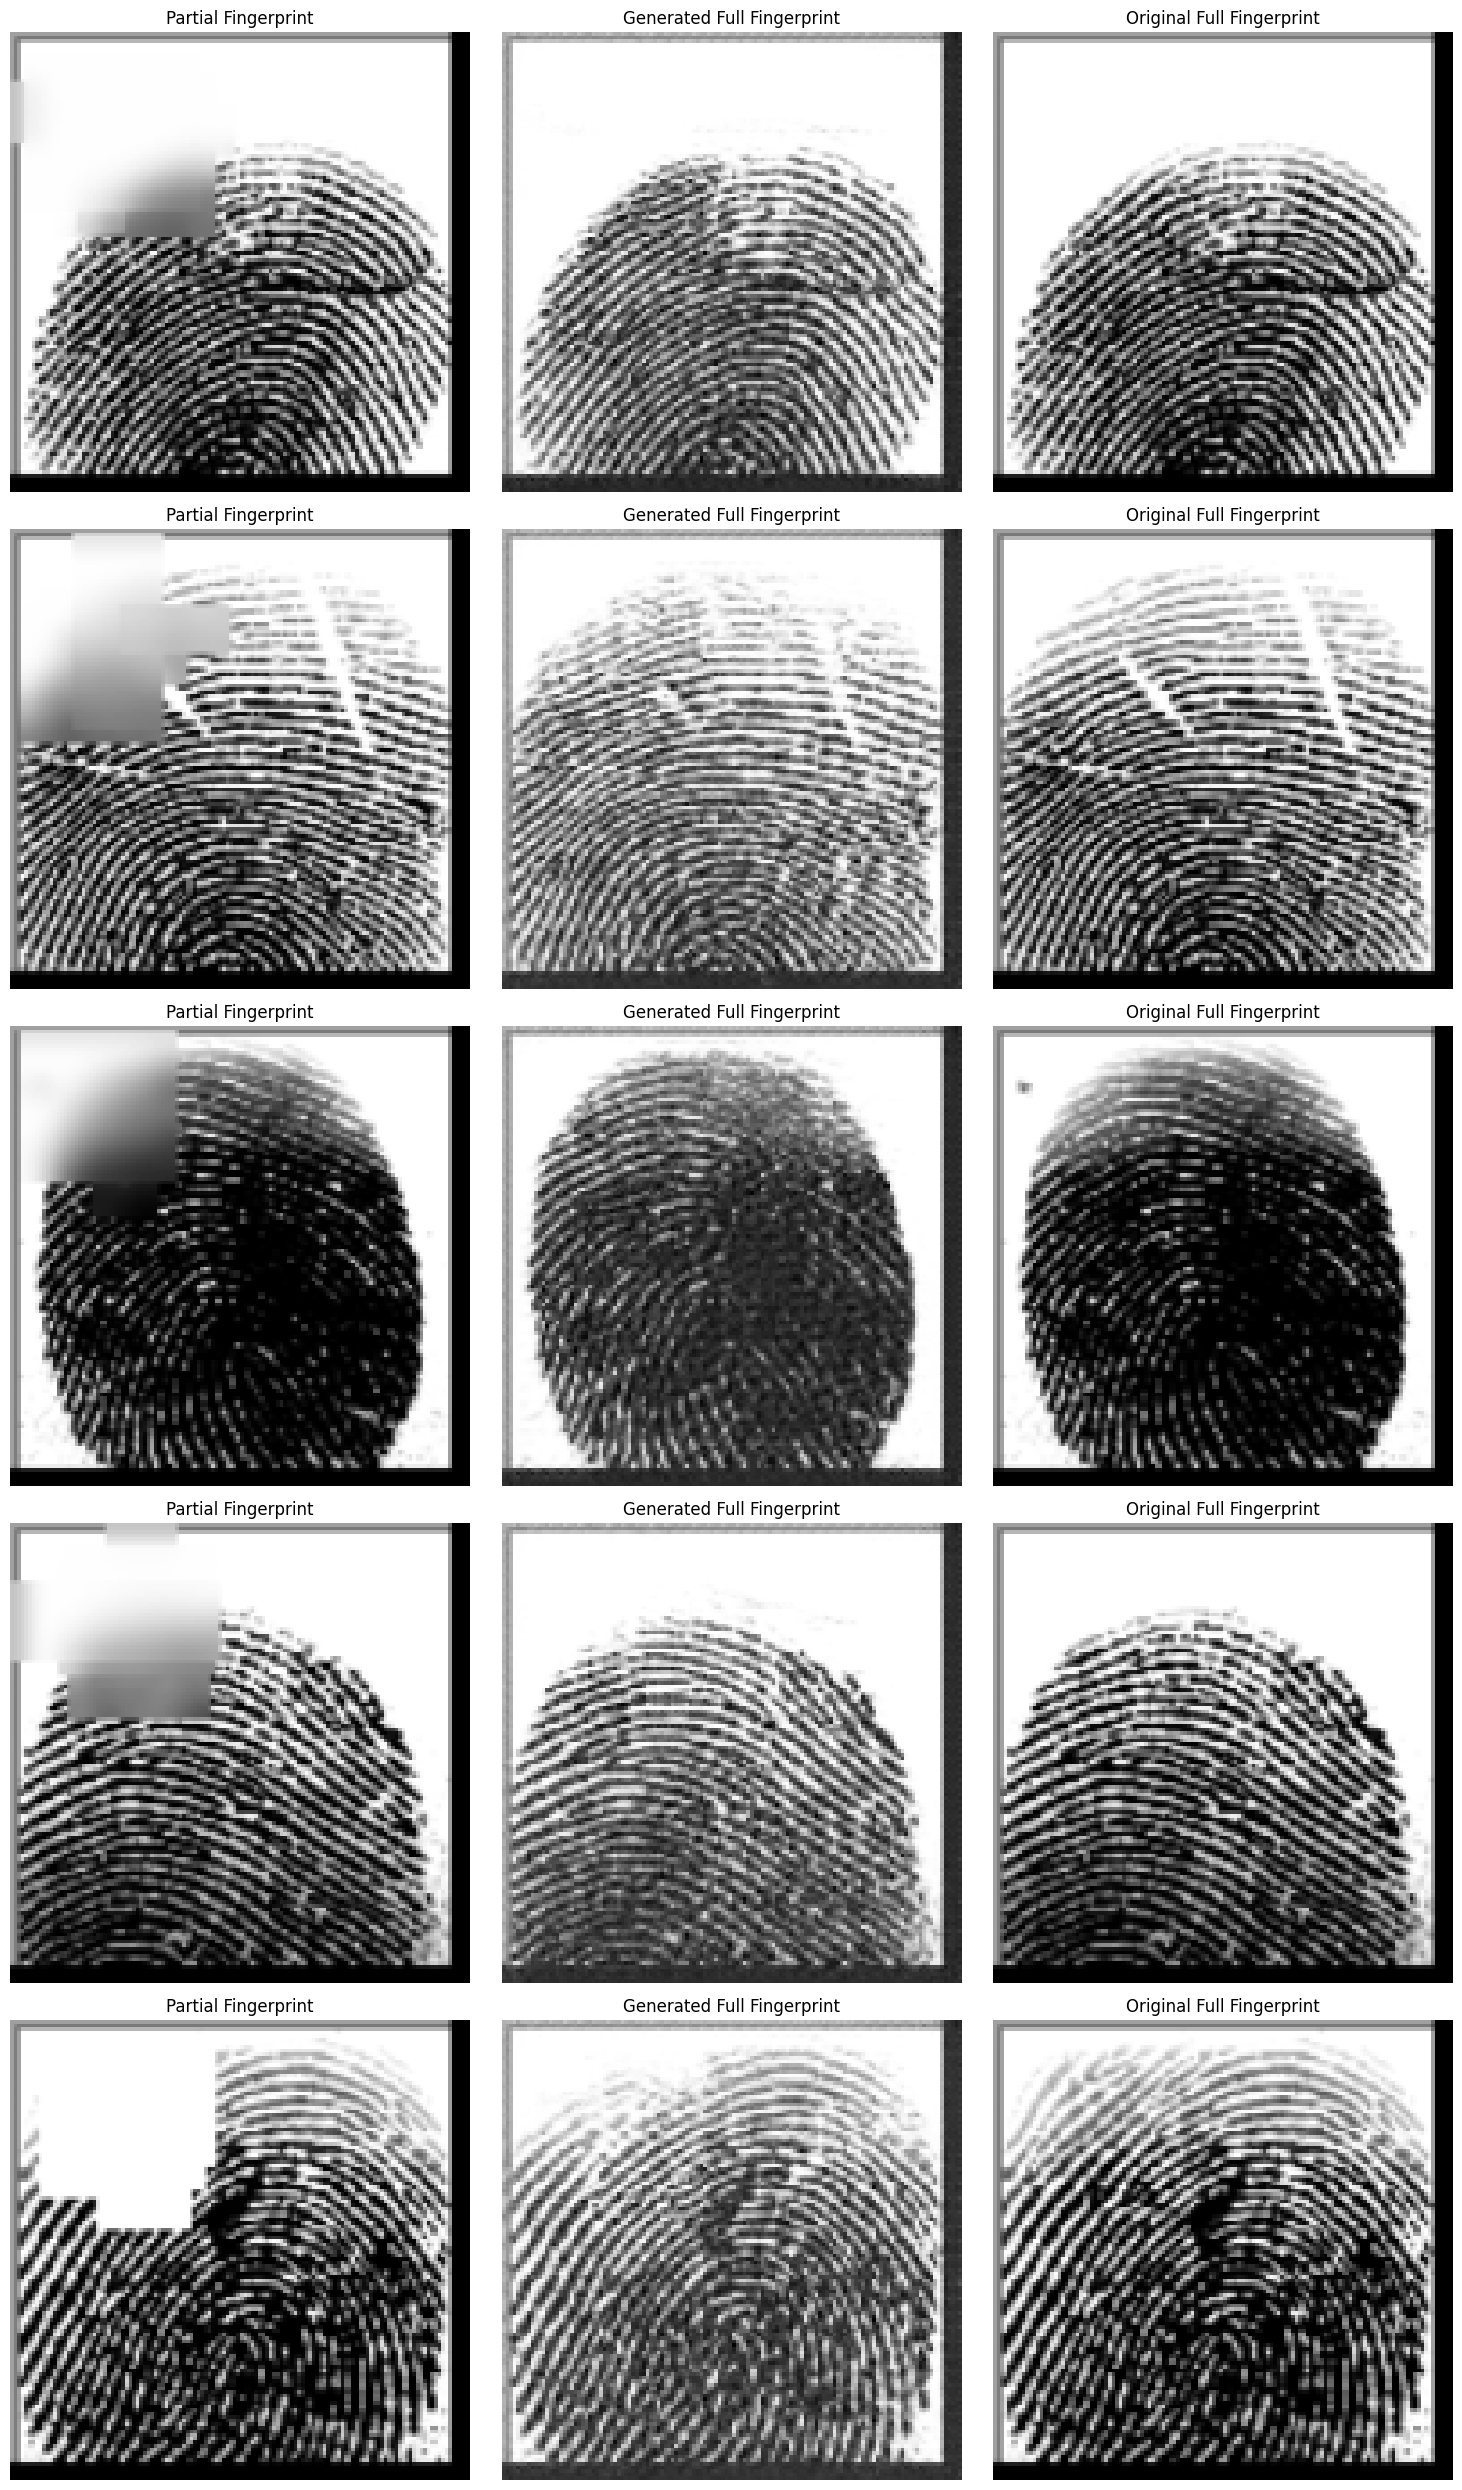

In [11]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


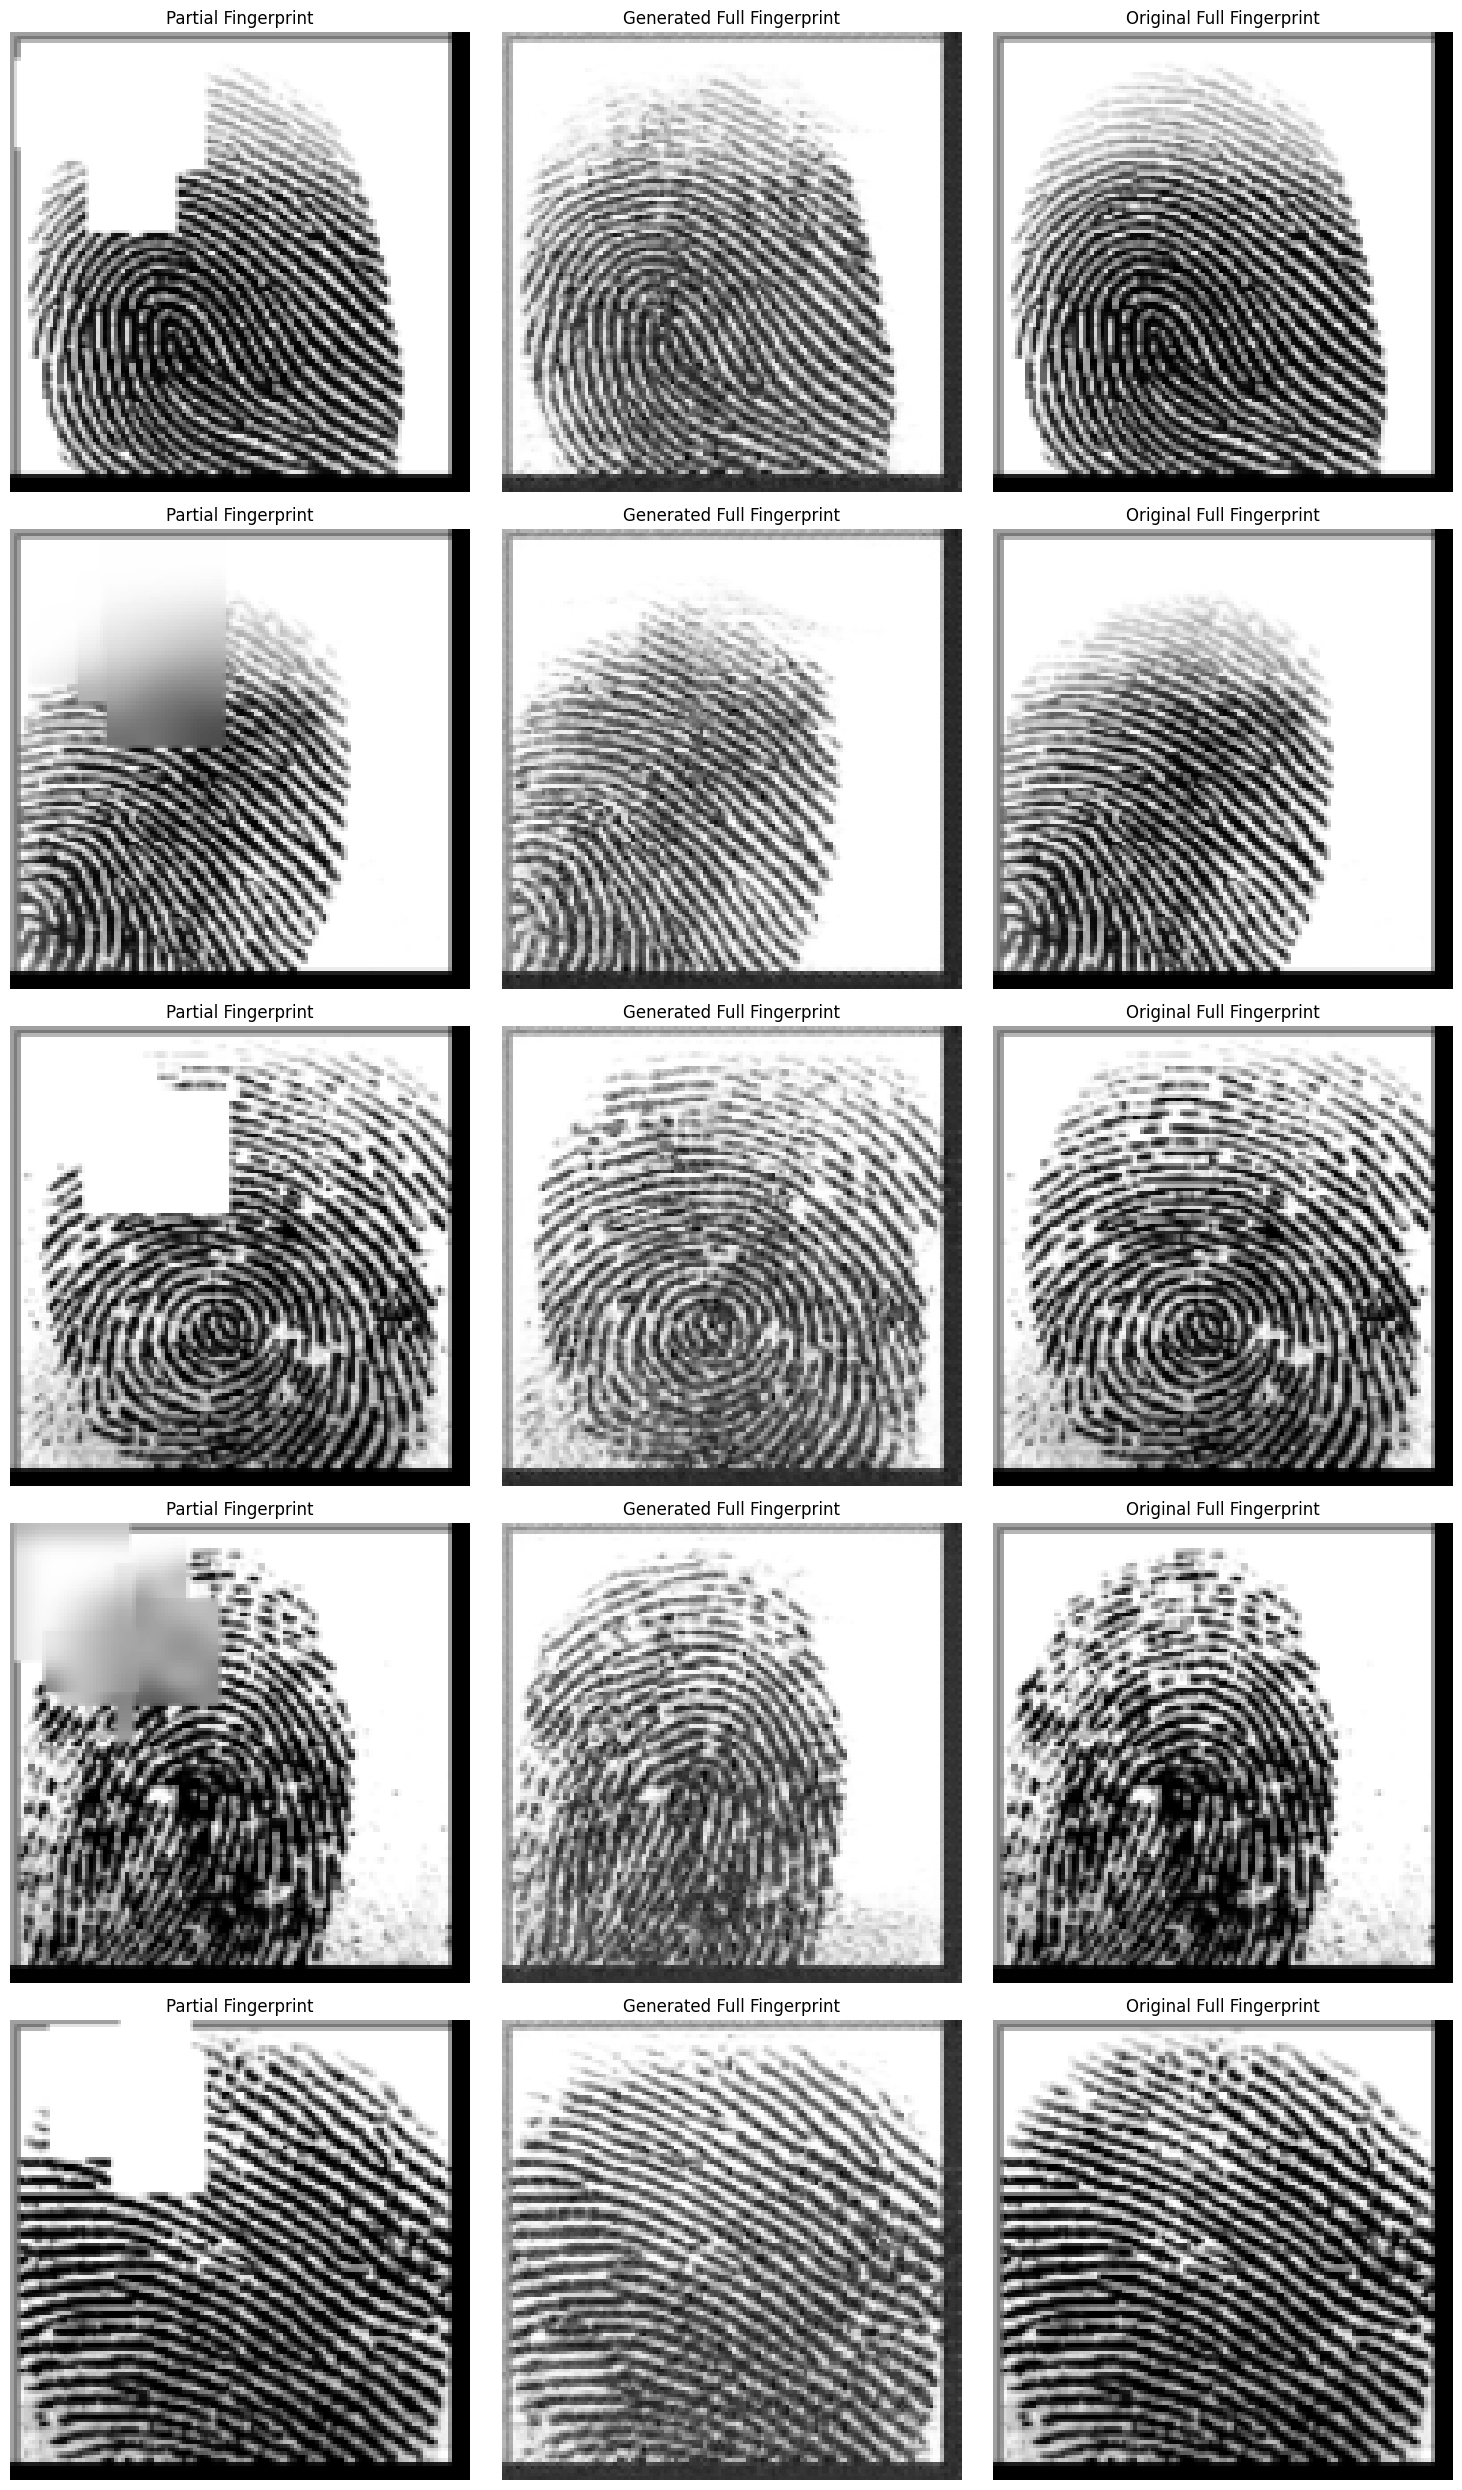

In [13]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


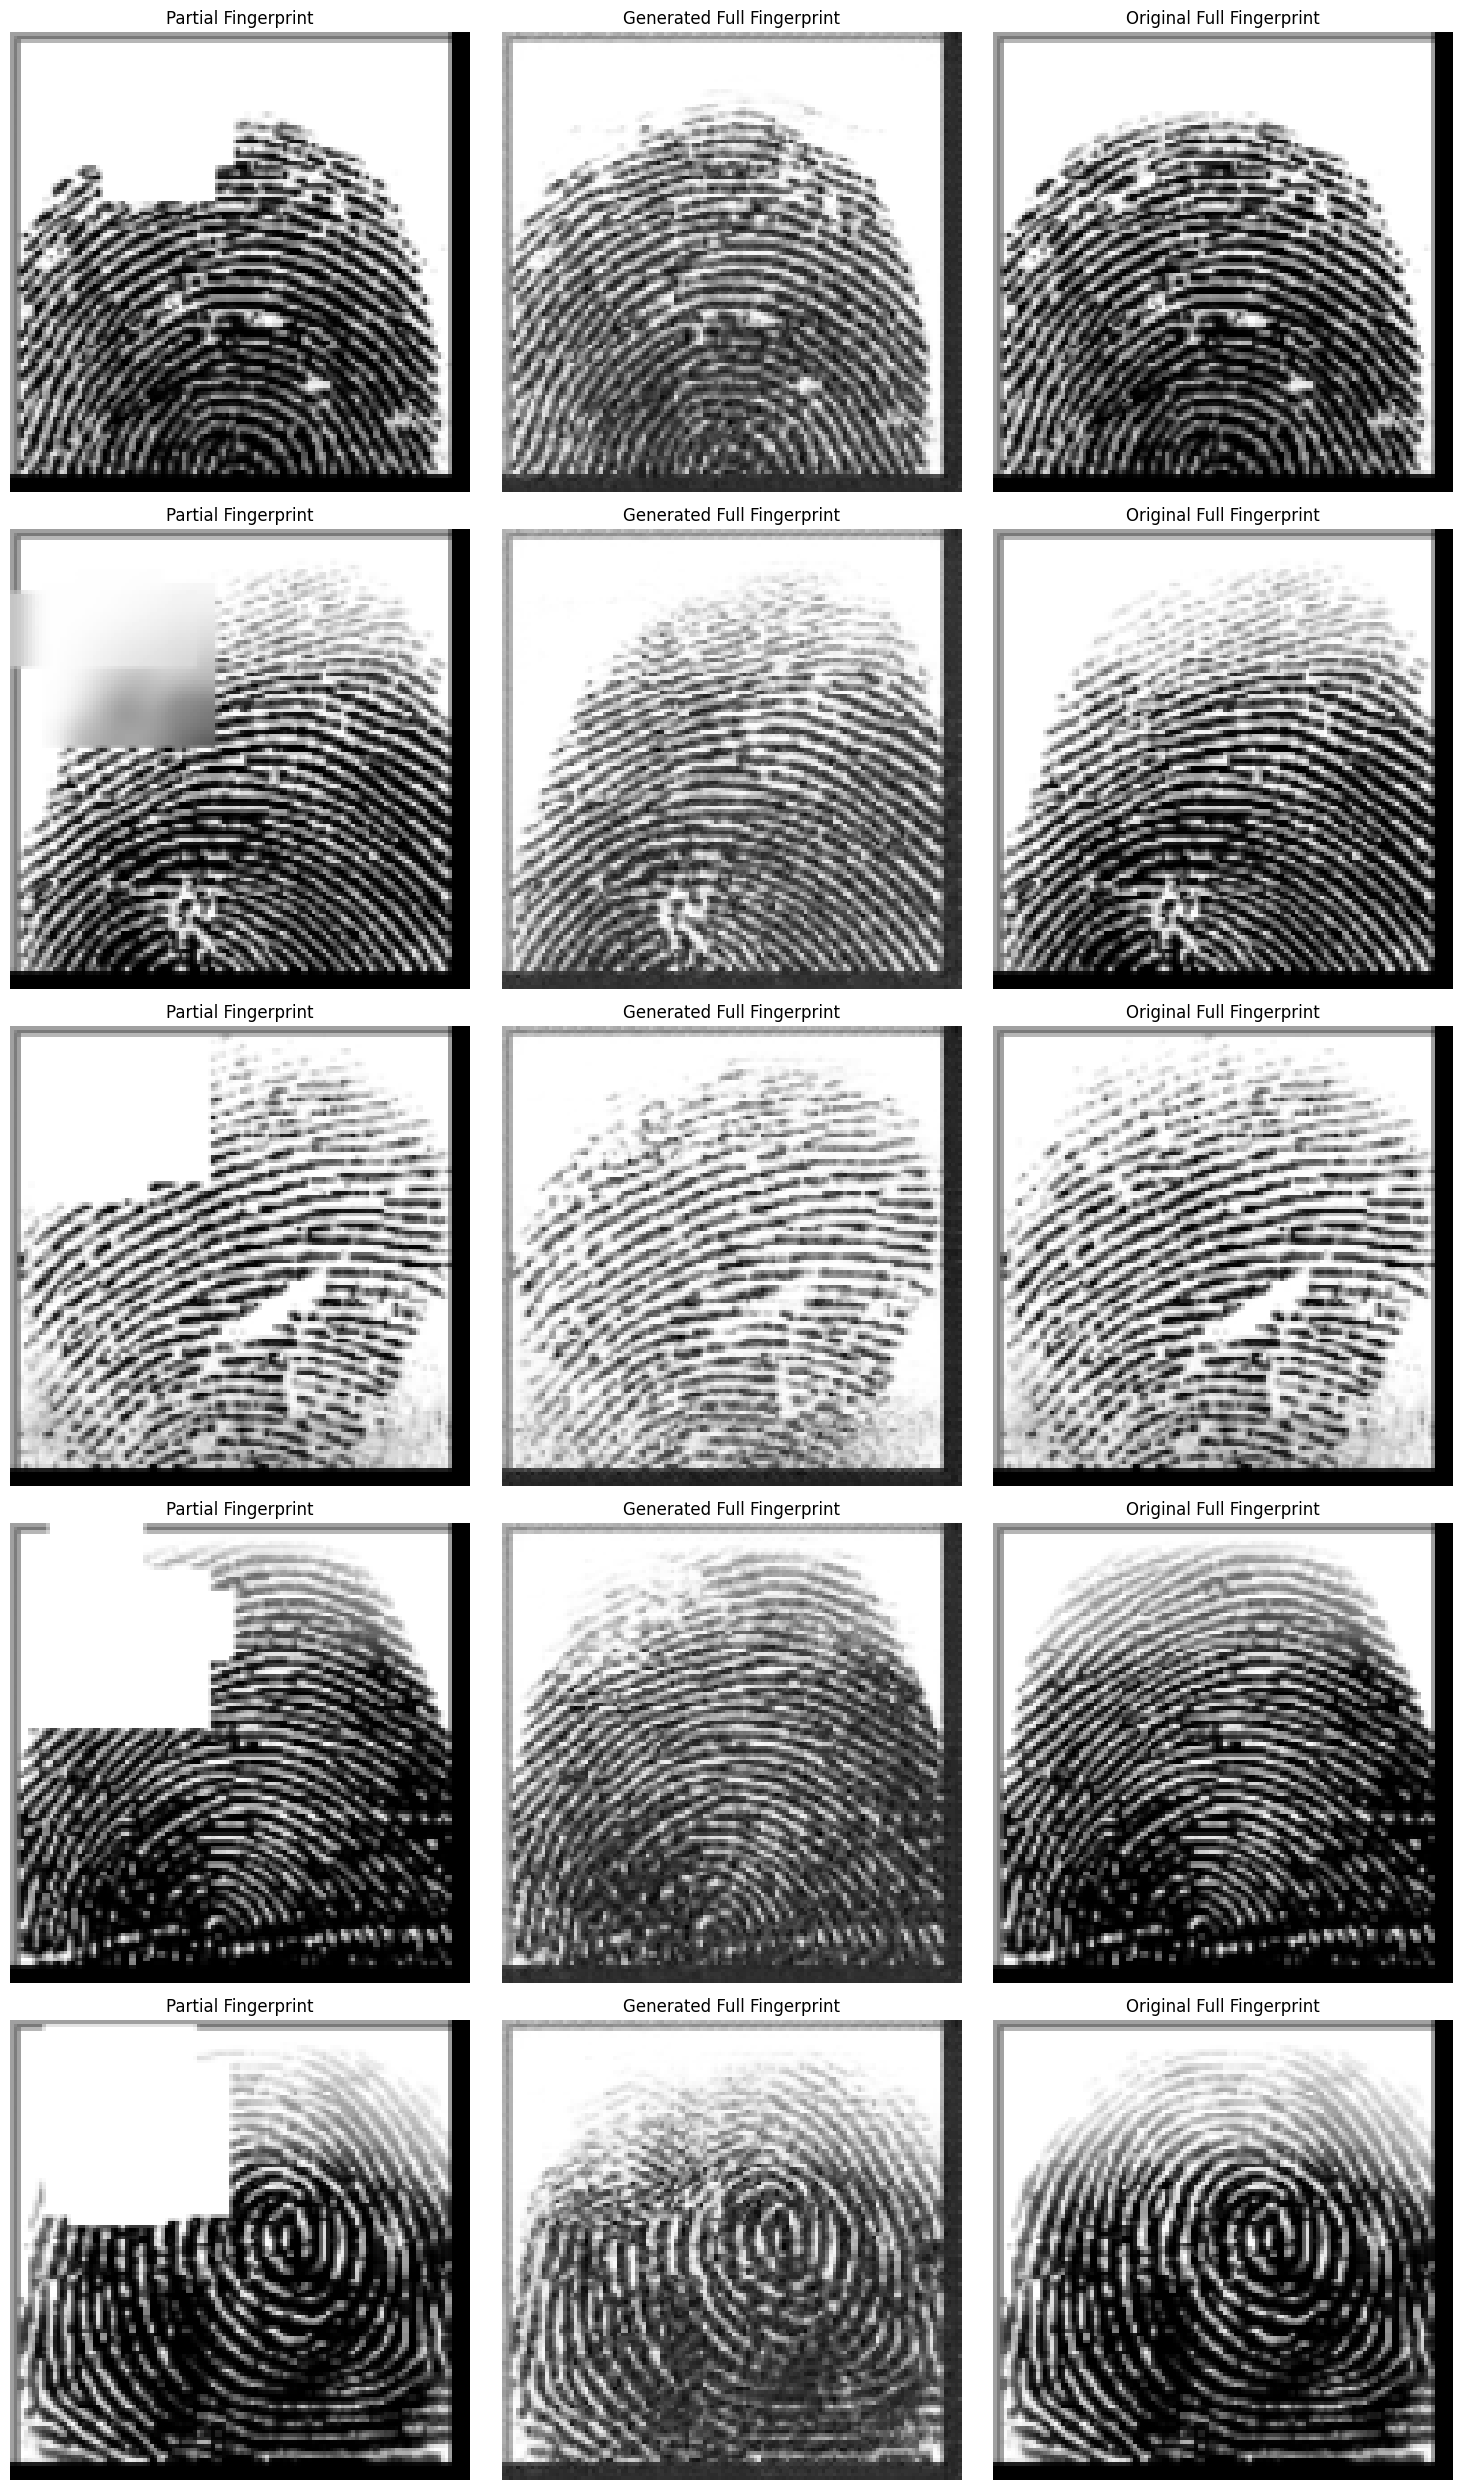

In [14]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


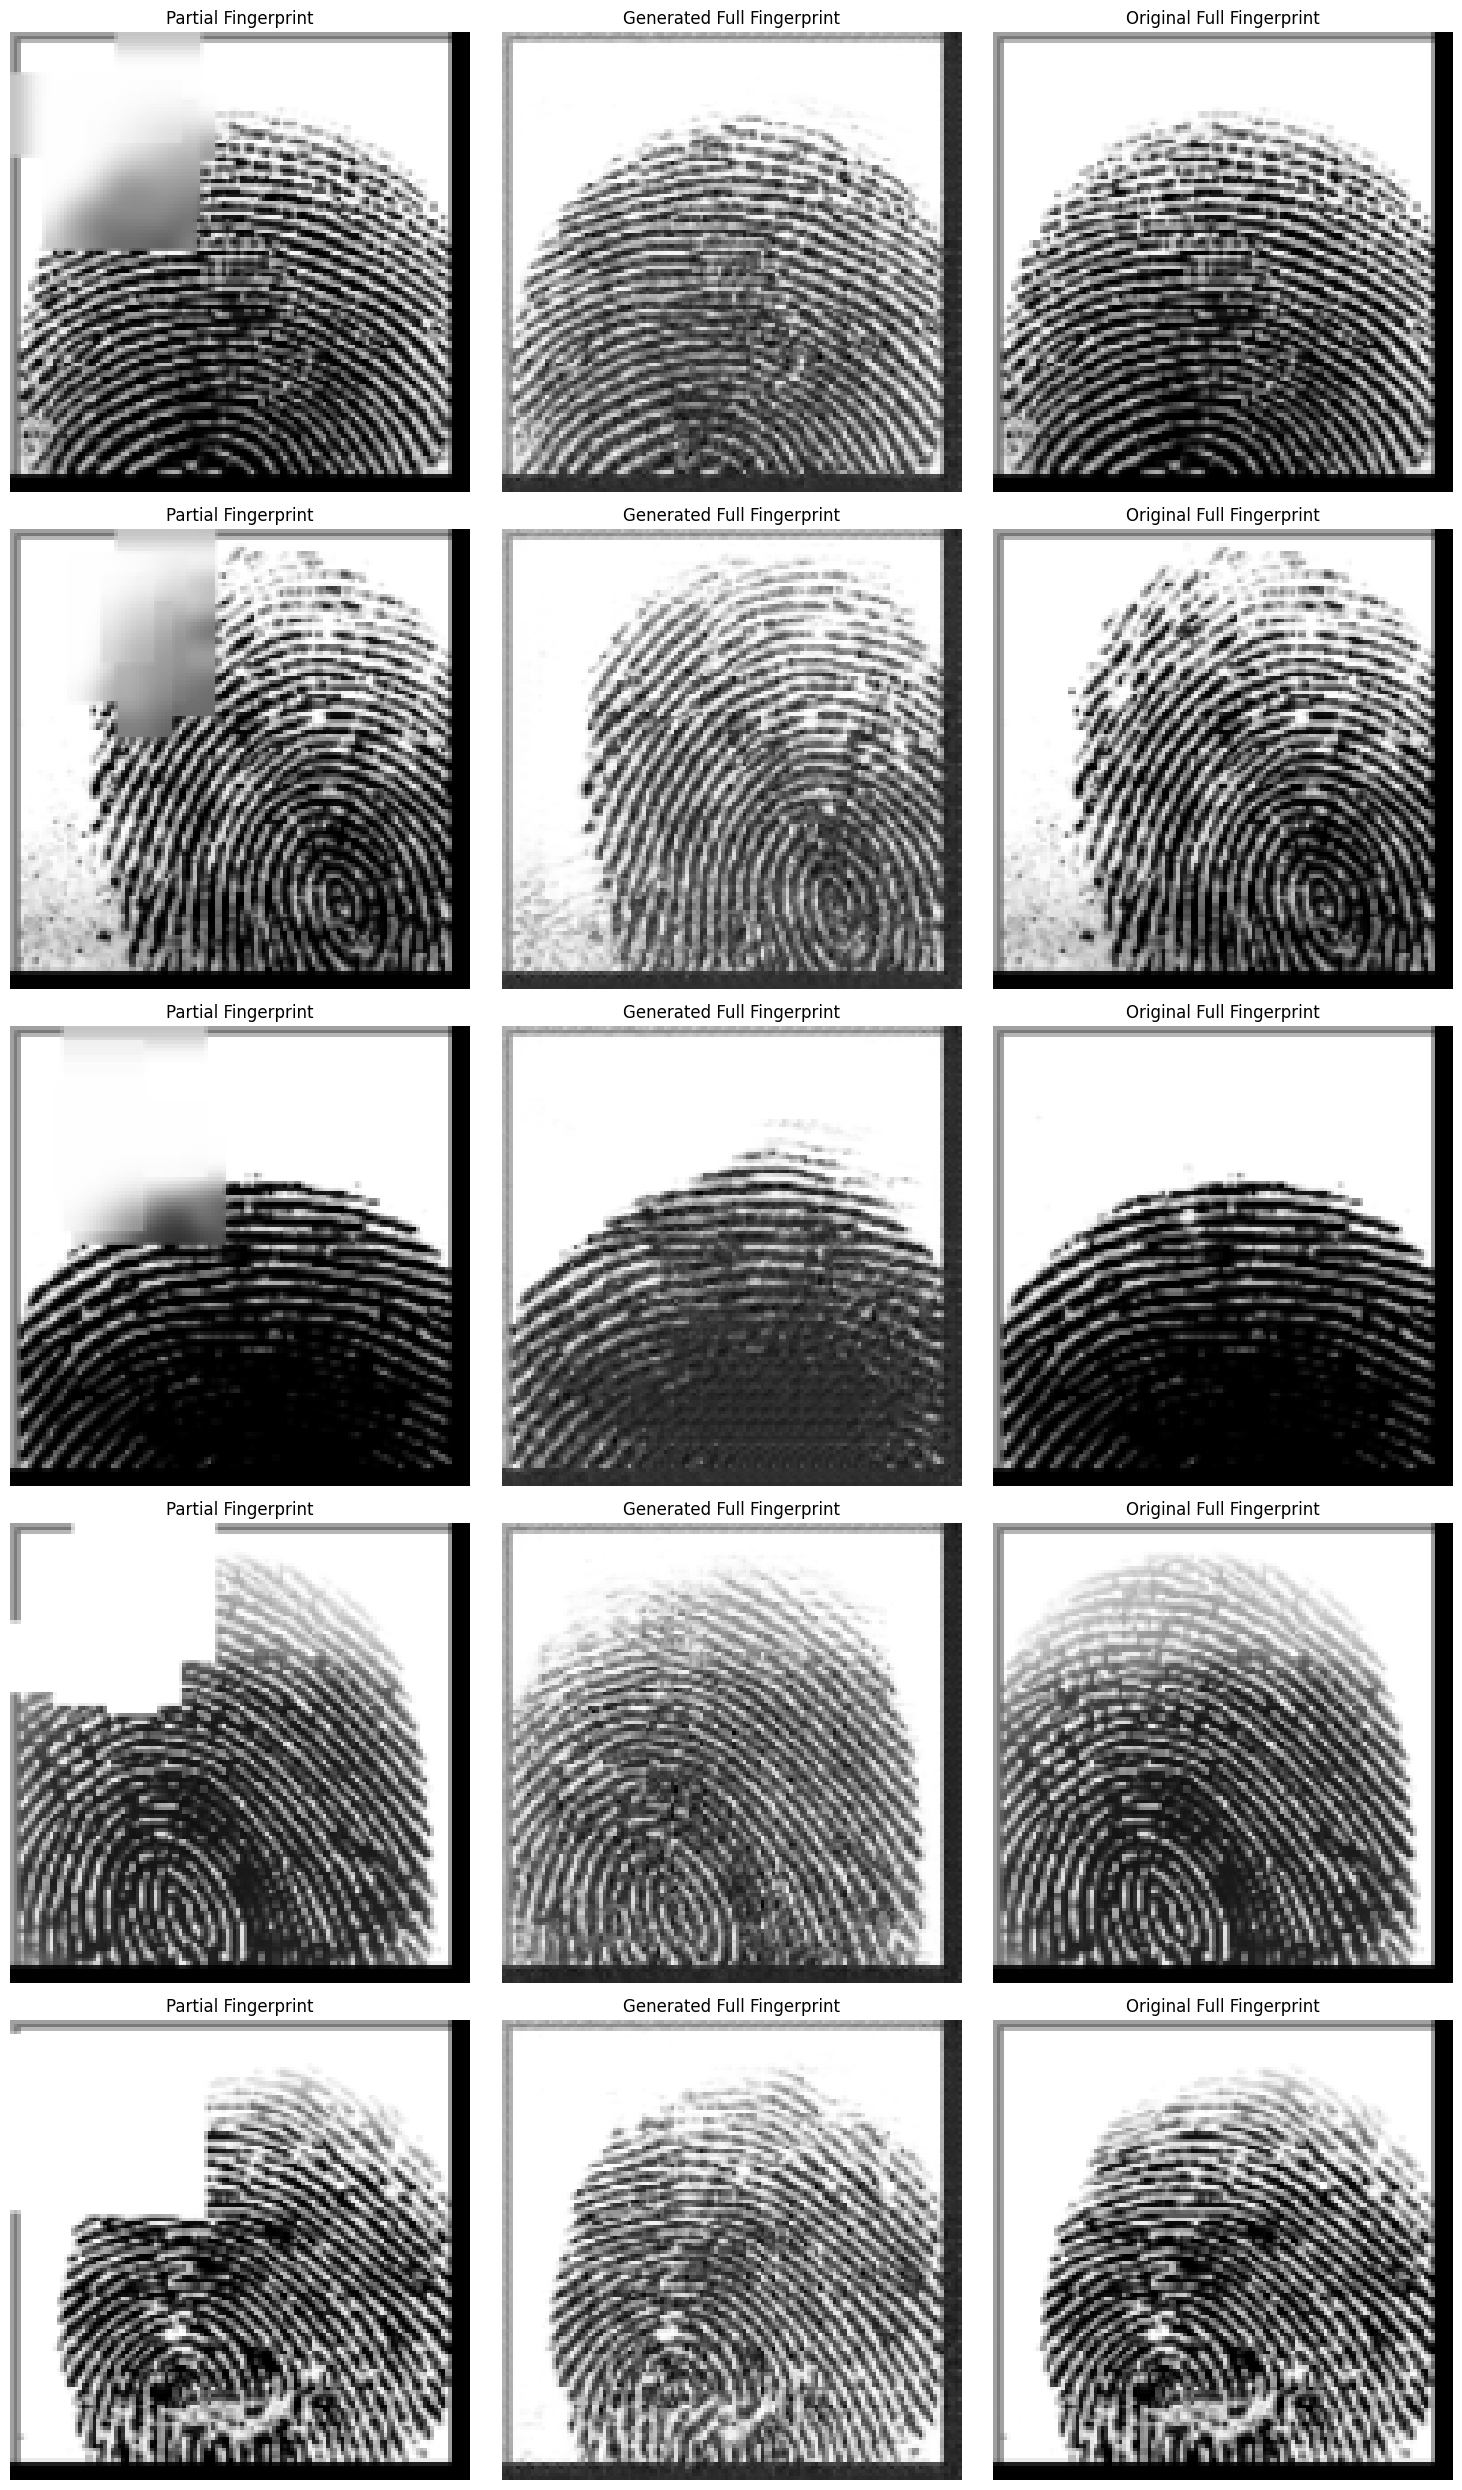

In [15]:
import torch
import matplotlib.pyplot as plt

# Function to generate full images (fingerprints) from partial images
def generate_full_fingerprints(generator, dataloader, num_images=5):
    generator.eval()  # Set the generator to evaluation mode
    partial_fingerprints, real_fingerprints = next(iter(dataloader))  # Get a batch of data
    partial_fingerprints = partial_fingerprints[:num_images].to(device)  # Select a few images
    real_fingerprints = real_fingerprints[:num_images].to(device)  # Select the corresponding original images

    # Generate full fingerprints using the generator
    with torch.no_grad():
        generated_fingerprints = generator(partial_fingerprints)

    # Visualize partial, generated, and real fingerprints
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5*num_images))  # Adjust ncols to 3 for 3 images per row
    for i in range(num_images):
        # Display partial fingerprint
        axes[i, 0].imshow(partial_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 0].set_title('Partial Fingerprint')
        axes[i, 0].axis('off')

        # Display generated full fingerprint
        axes[i, 1].imshow(generated_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Generated Full Fingerprint')
        axes[i, 1].axis('off')

        # Display original full fingerprint
        axes[i, 2].imshow(real_fingerprints[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Original Full Fingerprint')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Generate and visualize full fingerprints
generate_full_fingerprints(generator, dataloader, num_images=5)


## 6. Saving the model

In [16]:
import torch

# Function to save the GAN model
def save_gan_model(generator, discriminator, optimizer_G, optimizer_D, epoch, save_path="/kaggle/working/FingerPrint_model.pth"):
    # Create a dictionary containing the models and optimizers' state dicts
    checkpoint = {
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'epoch': epoch
    }
    
    # Save the checkpoint to the given path
    torch.save(checkpoint, save_path)
    print(f"Model saved successfully at epoch {epoch} in {save_path}")

# Example of usage after training
save_gan_model(generator, discriminator, optimizer_G, optimizer_D, epoch=10, save_path="/kaggle/working/FingerPrint_model.pth")


Model saved successfully at epoch 10 in /kaggle/working/FingerPrint_model.pth


## 7. Loading the model

In [22]:
import torch

# Function to load the GAN model
def load_gan_model(generator, discriminator, optimizer_G, optimizer_D, load_path="F_model.pth"):
    # Load the checkpoint from the file and map it to the appropriate device (CPU or GPU)
    checkpoint = torch.load(load_path)

    # Load the state dicts into the generator and discriminator
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

    # Load the state dicts into the optimizers
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])

    # Return the epoch to continue training from
    epoch = checkpoint['epoch']
    print(f"Model loaded successfully from {load_path}, resuming from epoch {epoch}")

    return epoch

# Example of usage when resuming from a checkpoint
start_epoch = load_gan_model(generator, discriminator, optimizer_G, optimizer_D, load_path = "/kaggle/working/FingerPrint_model.pth")

/tmp/ipykernel_36/1835090636.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(load_path)


Model loaded successfully from /kaggle/working/FingerPrint_model.pth, resuming from epoch 10


## 8. Checking model accuracy

In [17]:
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader

#### Function to evaluate the generator using SSIM (Structural Similarity Index) between generated and real images

In [18]:
def evaluate_generator_ssim(generator, dataloader, device):
    generator.eval()  # Set generator to evaluation mode
    total_ssim = 0.0
    count = 0

    with torch.no_grad():
        for partial_images, original_images in dataloader:
            partial_images = partial_images.to(device)
            original_images = original_images.to(device)

            # Generate images
            generated_images = generator(partial_images)

            # Compute SSIM between generated and original images
            for i in range(generated_images.size(0)):
                gen_img = generated_images[i].cpu().numpy().squeeze()  # Convert to numpy array and remove channel dimension
                orig_img = original_images[i].cpu().numpy().squeeze()

                # SSIM expects images in the range [0, 255]
                gen_img = (gen_img * 255).astype("uint8")
                orig_img = (orig_img * 255).astype("uint8")

                score = ssim(gen_img, orig_img, data_range=gen_img.max() - gen_img.min())
                total_ssim += score
                count += 1

    avg_ssim = total_ssim / count
    print(f"Average SSIM for generated images: {avg_ssim:.4f}")
    return avg_ssim

#### Function to evaluate the discriminator's accuracy on real and fake images

In [19]:
def evaluate_discriminator_accuracy(generator, discriminator, dataloader, device):
    generator.eval()
    discriminator.eval()
    real_correct = 0
    fake_correct = 0
    total = 0

    with torch.no_grad():
        for partial_images, original_images in dataloader:
            partial_images = partial_images.to(device)
            original_images = original_images.to(device)

            # Generate fake images
            generated_images = generator(partial_images)

            # Discriminator output for real images
            real_labels = torch.full((original_images.size(0),), 1.0, dtype=torch.float, device=device)
            real_output = discriminator(original_images).view(-1)
            real_correct += ((real_output > 0.5) == real_labels).sum().item()

            # Discriminator output for fake images
            fake_labels = torch.full((generated_images.size(0),), 0.0, dtype=torch.float, device=device)
            fake_output = discriminator(generated_images.detach()).view(-1)
            fake_correct += ((fake_output < 0.5) == fake_labels).sum().item()

            total += original_images.size(0)

    real_acc = real_correct / total * 100
    fake_acc = fake_correct / total * 100

    print(f"Discriminator Accuracy on Real Images: {real_acc:.2f}%")
    print(f"Discriminator Accuracy on Fake Images: {fake_acc:.2f}%")
    return real_acc, fake_acc

#### Evaluate the generator and discriminator

In [20]:
evaluate_generator_ssim(generator, dataloader, device)
evaluate_discriminator_accuracy(generator, discriminator, dataloader, device)

Average SSIM for generated images: 0.6127
Discriminator Accuracy on Real Images: 99.88%
Discriminator Accuracy on Fake Images: 91.98%


(99.88333333333334, 91.98333333333333)